# Import data

In [104]:
import pandas as pd
import geopandas as gpd
import polars as pl
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import math
#from utilities.Countries import city_to_country
#from utilities.DE_regions import city_to_state

In [105]:
calls = pl.read_csv('../raw_and_clean_data/Calls.csv')
contacts = pl.read_csv('../raw_and_clean_data/Contacts.csv')
deals = pl.read_csv('../raw_and_clean_data/Deals.csv')
spend = pl.read_csv('../raw_and_clean_data/Spend.csv')

In [106]:
calls_raw = calls
deals_raw = deals
contacts_raw = contacts
spend_raw = spend
print("Backups have been created. You can experiment on the main tables!")

Backups have been created. You can experiment on the main tables!


# Data Cleaning and Preparation

1. Remove duplicate records and irrelevant columns.
2. Properly handle missing values.
3. Convert data types for columns such as dates and numerical values.

## Calls - Inspection, cleaning and transformation

In [107]:
# Inspection

In [108]:
calls = pl.read_csv('../raw_and_clean_data/Calls.csv')

In [109]:
calls.head()

Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Dialled Number,Outgoing Call Status,Scheduled in CRM,Tag
i64,str,str,i64,str,i64,str,str,str,bool,str
5805028000000805001,"""30.06.2023 08:43""","""John Doe""",null,"""Inbound""",171,"""Received""",null,null,null,null
5805028000000768006,"""30.06.2023 08:46""","""John Doe""",null,"""Outbound""",28,"""Attended Dialled""",null,"""Completed""",false,null
5805028000000764027,"""30.06.2023 08:59""","""John Doe""",null,"""Outbound""",24,"""Attended Dialled""",null,"""Completed""",false,null
5805028000000787003,"""30.06.2023 09:20""","""John Doe""",5805028000000645014,"""Outbound""",6,"""Attended Dialled""",null,"""Completed""",false,null
5805028000000768019,"""30.06.2023 09:30""","""John Doe""",5805028000000645014,"""Outbound""",11,"""Attended Dialled""",null,"""Completed""",false,null


In [110]:
calls.schema

Schema([('Id', Int64),
        ('Call Start Time', String),
        ('Call Owner Name', String),
        ('CONTACTID', Int64),
        ('Call Type', String),
        ('Call Duration (in seconds)', Int64),
        ('Call Status', String),
        ('Dialled Number', String),
        ('Outgoing Call Status', String),
        ('Scheduled in CRM', Boolean),
        ('Tag', String)])

In [111]:
calls.describe()

statistic,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Dialled Number,Outgoing Call Status,Scheduled in CRM,Tag
str,f64,str,str,f64,str,f64,str,str,str,f64,str
"""count""",95871.0,"""95871""","""95871""",91938.0,"""95871""",95788.0,"""95871""","""0""","""86872""",86872.0,"""0"""
"""null_count""",0.0,"""0""","""0""",3933.0,"""0""",83.0,"""0""","""95871""","""8999""",8999.0,"""95871"""
"""mean""",5.8050e18,null,null,5.8050e18,null,164.981772,null,null,null,0.001635,null
"""std""",1.5849e7,null,null,1.5704e7,null,401.416302,null,null,null,null,null
"""min""",5.8050e18,"""01.01.2024 08:06""","""Alice Johnson""",5.8050e18,"""Inbound""",0.0,"""Attended Dialled""",null,"""Cancelled""",0.0,null
"""25%""",5.8050e18,null,null,5.8050e18,null,4.0,null,null,null,null,null
"""50%""",5.8050e18,null,null,5.8050e18,null,8.0,null,null,null,null,null
"""75%""",5.8050e18,null,null,5.8050e18,null,98.0,null,null,null,null,null
"""max""",5.8050e18,"""31.12.2023 23:25""","""Zachary Foster""",5.8050e18,"""Outbound""",7625.0,"""Unattended Dialled""",null,"""Scheduled""",1.0,null


In [112]:
calls.describe()

statistic,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Dialled Number,Outgoing Call Status,Scheduled in CRM,Tag
str,f64,str,str,f64,str,f64,str,str,str,f64,str
"""count""",95871.0,"""95871""","""95871""",91938.0,"""95871""",95788.0,"""95871""","""0""","""86872""",86872.0,"""0"""
"""null_count""",0.0,"""0""","""0""",3933.0,"""0""",83.0,"""0""","""95871""","""8999""",8999.0,"""95871"""
"""mean""",5.8050e18,null,null,5.8050e18,null,164.981772,null,null,null,0.001635,null
"""std""",1.5849e7,null,null,1.5704e7,null,401.416302,null,null,null,null,null
"""min""",5.8050e18,"""01.01.2024 08:06""","""Alice Johnson""",5.8050e18,"""Inbound""",0.0,"""Attended Dialled""",null,"""Cancelled""",0.0,null
"""25%""",5.8050e18,null,null,5.8050e18,null,4.0,null,null,null,null,null
"""50%""",5.8050e18,null,null,5.8050e18,null,8.0,null,null,null,null,null
"""75%""",5.8050e18,null,null,5.8050e18,null,98.0,null,null,null,null,null
"""max""",5.8050e18,"""31.12.2023 23:25""","""Zachary Foster""",5.8050e18,"""Outbound""",7625.0,"""Unattended Dialled""",null,"""Scheduled""",1.0,null


In [113]:
# Count values

# print( "poloars will not display all columns aplying 'print'. We force it (with) to show us all columns.")

total_unique_rows = calls.n_unique()       # returns a single number (how many unique rows there are in total)
print("Unique values:", total_unique_rows)

with pl.Config(tbl_rows=12):               # Force display of 12 rows, our dataset has 12 columns
    print(calls.count().unpivot())

Unique values: 95871
shape: (11, 2)
┌────────────────────────────┬───────┐
│ variable                   ┆ value │
│ ---                        ┆ ---   │
│ str                        ┆ u32   │
╞════════════════════════════╪═══════╡
│ Id                         ┆ 95871 │
│ Call Start Time            ┆ 95871 │
│ Call Owner Name            ┆ 95871 │
│ CONTACTID                  ┆ 91938 │
│ Call Type                  ┆ 95871 │
│ Call Duration (in seconds) ┆ 95788 │
│ Call Status                ┆ 95871 │
│ Dialled Number             ┆ 0     │
│ Outgoing Call Status       ┆ 86872 │
│ Scheduled in CRM           ┆ 86872 │
│ Tag                        ┆ 0     │
└────────────────────────────┴───────┘


In [114]:
# Identify and inspect duplicates
duplicates = calls.filter(calls.is_duplicated())
print("Sample of duplicated rows:")
print(duplicates.head(10))

Sample of duplicated rows:
shape: (0, 11)
┌─────┬───────────────┬──────────────┬───────────┬───┬─────────┬──────────────┬──────────────┬─────┐
│ Id  ┆ Call Start    ┆ Call Owner   ┆ CONTACTID ┆ … ┆ Dialled ┆ Outgoing     ┆ Scheduled in ┆ Tag │
│ --- ┆ Time          ┆ Name         ┆ ---       ┆   ┆ Number  ┆ Call Status  ┆ CRM          ┆ --- │
│ i64 ┆ ---           ┆ ---          ┆ i64       ┆   ┆ ---     ┆ ---          ┆ ---          ┆ str │
│     ┆ str           ┆ str          ┆           ┆   ┆ str     ┆ str          ┆ bool         ┆     │
╞═════╪═══════════════╪══════════════╪═══════════╪═══╪═════════╪══════════════╪══════════════╪═════╡
└─────┴───────────────┴──────────────┴───────────┴───┴─────────┴──────────────┴──────────────┴─────┘


In [115]:
# Checking for duplicate IDs

# Filter the dataframe to show only rows where the 'Id' is repeated
duplicate_ids = calls.filter(pl.col("Id").is_duplicated())

# Count how many duplicate IDs exist
duplicate_count = duplicate_ids.height

if duplicate_count > 0:
    print(f"Warning: Found {duplicate_count} rows with duplicate IDs.")
    print(duplicate_ids.sort("Id").head(10)) # Sort to see the identical IDs next to each other
else:
    print("Success: No duplicate IDs found. Every contact is unique.")

Success: No duplicate IDs found. Every contact is unique.


In [116]:
# Transformation & cleaning

In [117]:
# Standardize column names
calls = calls.rename({col: col.replace(" ", "_") for col in calls.columns})

# Transformation & Cleaning Pipeline
print(f"Number of rows before removing duplicates: {calls.height}")

calls = (
    calls
    .unique() # Remove duplicates
    .drop(["Dialled_Number", "Tag"]) # Remove irrelevant columns
    .with_columns([
        # Convert string timestamps to Datetime
        pl.col("Call_Start_Time").str.to_datetime("%d.%m.%Y %H:%M"),
        pl.col("Call_Duration_(in_seconds)").cast(pl.Int32, strict=False),
        
        # Handle missing CONTACTID (using 0 as placeholder)
        pl.col("CONTACTID").fill_null(0).cast(pl.Int64)
    ])
)

print(f"Number of rows after removing duplicates: {calls.height}")


Number of rows before removing duplicates: 95871
Number of rows after removing duplicates: 95871


In [118]:
calls.schema

Schema([('Id', Int64),
        ('Call_Start_Time', Datetime(time_unit='us', time_zone=None)),
        ('Call_Owner_Name', String),
        ('CONTACTID', Int64),
        ('Call_Type', String),
        ('Call_Duration_(in_seconds)', Int32),
        ('Call_Status', String),
        ('Outgoing_Call_Status', String),
        ('Scheduled_in_CRM', Boolean)])

## Contacts - Inspection, cleaning and transformation

In [119]:
# Inspection

In [120]:
contacts = pl.read_csv('../raw_and_clean_data/Contacts.csv')

In [121]:
print("Table head", contacts.head(10))
print("Data types", contacts.dtypes)
print(contacts.describe())

Table head shape: (10, 4)
┌─────────────────────┬────────────────────┬──────────────────┬──────────────────┐
│ Id                  ┆ Contact Owner Name ┆ Created Time     ┆ Modified Time    │
│ ---                 ┆ ---                ┆ ---              ┆ ---              │
│ i64                 ┆ str                ┆ str              ┆ str              │
╞═════════════════════╪════════════════════╪══════════════════╪══════════════════╡
│ 5805028000000645014 ┆ Rachel White       ┆ 27.06.2023 11:28 ┆ 22.12.2023 13:34 │
│ 5805028000000872003 ┆ Charlie Davis      ┆ 03.07.2023 11:31 ┆ 21.05.2024 10:23 │
│ 5805028000000889001 ┆ Bob Brown          ┆ 02.07.2023 22:37 ┆ 21.12.2023 13:17 │
│ 5805028000000907006 ┆ Bob Brown          ┆ 03.07.2023 05:44 ┆ 29.12.2023 15:20 │
│ 5805028000000939010 ┆ Nina Scott         ┆ 04.07.2023 10:11 ┆ 16.04.2024 16:14 │
│ 5805028000000942003 ┆ Alice Johnson      ┆ 04.07.2023 12:57 ┆ 17.07.2023 19:43 │
│ 5805028000000961001 ┆ Bob Brown          ┆ 03.07.2023 20:17

In [122]:
contacts.schema

Schema([('Id', Int64),
        ('Contact Owner Name', String),
        ('Created Time', String),
        ('Modified Time', String)])

In [123]:
# Count values

In [124]:
# print( "poloars will not display all columns aplying 'print'. We force it (with) to show us all columns.")

total_unique_rows = contacts.n_unique()       # returns a single number (how many unique rows there are in total)
print("Unique values:", total_unique_rows)

with pl.Config(tbl_rows=12):               # Force display of 12 rows, our dataset has 12 columns
    print(contacts.count().unpivot())

Unique values: 18548
shape: (4, 2)
┌────────────────────┬───────┐
│ variable           ┆ value │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ Id                 ┆ 18548 │
│ Contact Owner Name ┆ 18548 │
│ Created Time       ┆ 18548 │
│ Modified Time      ┆ 18548 │
└────────────────────┴───────┘


In [125]:
# Identify and inspect duplicates
duplicates = contacts.filter(contacts.is_duplicated())
print("Sample of duplicated rows:")
print(duplicates.head(10))

Sample of duplicated rows:
shape: (0, 4)
┌─────┬────────────────────┬──────────────┬───────────────┐
│ Id  ┆ Contact Owner Name ┆ Created Time ┆ Modified Time │
│ --- ┆ ---                ┆ ---          ┆ ---           │
│ i64 ┆ str                ┆ str          ┆ str           │
╞═════╪════════════════════╪══════════════╪═══════════════╡
└─────┴────────────────────┴──────────────┴───────────────┘


In [126]:
# Checking for duplicate Contact IDs

# Filter the dataframe to show only rows where the 'Id' is repeated
duplicate_ids = contacts.filter(pl.col("Id").is_duplicated())

# Count how many duplicate IDs exist
duplicate_count = duplicate_ids.height

if duplicate_count > 0:
    print(f"Warning: Found {duplicate_count} rows with duplicate IDs.")
    print(duplicate_ids.sort("Id").head(10)) # Sort to see the identical IDs next to each other
else:
    print("Success: No duplicate IDs found. Every contact is unique.")

Success: No duplicate IDs found. Every contact is unique.


In [127]:
# Transformation & cleaning

In [128]:
# Standardize column names by replacing spaces with underscores
contacts = contacts.rename({col: col.replace(" ", "_") for col in contacts.columns})

# Transformation & Cleaning Pipeline



contacts = (
    contacts
    #.unique() # Remove duplicates, not needed in this case
    .with_columns([
        # Convert string timestamps to Datetime
        pl.col("Created_Time").str.to_datetime("%d.%m.%Y %H:%M"),
        pl.col("Modified_Time").str.to_datetime("%d.%m.%Y %H:%M")
    ])
)
"""
# Remove duplicates
print(f"Number of rows before removing duplicates: {contacts.height}")
contacts = contacts.unique() # Remove duplicates, not needed in this case
print(f"Number of rows after removing duplicates: {contacts.height}")"""


'\n# Remove duplicates\nprint(f"Number of rows before removing duplicates: {contacts.height}")\ncontacts = contacts.unique() # Remove duplicates, not needed in this case\nprint(f"Number of rows after removing duplicates: {contacts.height}")'

In [129]:
contacts.schema

Schema([('Id', Int64),
        ('Contact_Owner_Name', String),
        ('Created_Time', Datetime(time_unit='us', time_zone=None)),
        ('Modified_Time', Datetime(time_unit='us', time_zone=None))])

## Deals - Inspection, cleaning and transformation

In [130]:
deals = pl.read_csv('../raw_and_clean_data/Deals.csv')

In [131]:
# Inspection

In [132]:
deals.head(5)

Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,Term,Source,Payment Type,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,i64,str,str
5805028000056864695,"""Ben Hall""",null,null,"""New Lead""",null,"""/eng/test""","""03.07.23women""",null,"""v16""","""women""","""Facebook Ads""",null,null,null,"""21.06.2024 15:30""",null,null,null,null,5805028000056849495,null,null
5805028000056859489,"""Ulysses Adams""",null,null,"""New Lead""",null,"""/at-eng""",null,null,null,null,"""Organic""",null,"""Web Developer""","""Morning""","""21.06.2024 15:23""",6,null,"""0.00""","""2,000.00""",5805028000056834471,null,null
5805028000056832357,"""Ulysses Adams""","""21.06.2024""","""D - Non Target""","""Lost""","""Non target""","""/at-eng""","""engwien_AT""","""0:26:43""","""b1-at""","""21_06_2024""","""Telegram posts""",null,null,null,"""21.06.2024 14:45""",null,null,null,null,5805028000056854421,null,null
5805028000056824246,"""Eva Kent""","""21.06.2024""","""E - Non Qualified""","""Lost""","""Invalid number""","""/eng""","""04.07.23recentlymoved_DE""","""1:00:04""","""bloggersvideo14com""","""recentlymoved""","""Facebook Ads""",null,null,null,"""21.06.2024 13:32""",null,null,null,null,5805028000056889351,null,null
5805028000056873292,"""Ben Hall""","""21.06.2024""","""D - Non Target""","""Lost""","""Non target""","""/eng""","""discovery_DE""","""0:53:12""","""website""",null,"""Google Ads""",null,null,null,"""21.06.2024 13:21""",null,null,null,null,5805028000056876176,null,null


In [133]:
deals.schema

Schema([('Id', Int64),
        ('Deal Owner Name', String),
        ('Closing Date', String),
        ('Quality', String),
        ('Stage', String),
        ('Lost Reason', String),
        ('Page', String),
        ('Campaign', String),
        ('SLA', String),
        ('Content', String),
        ('Term', String),
        ('Source', String),
        ('Payment Type', String),
        ('Product', String),
        ('Education Type', String),
        ('Created Time', String),
        ('Course duration', Int64),
        ('Months of study', String),
        ('Initial Amount Paid', String),
        ('Offer Total Amount', String),
        ('Contact Name', Int64),
        ('City', String),
        ('Level of Deutsch', String)])

In [134]:
deals.describe()

statistic,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,Term,Source,Payment Type,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch
str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,str,str
"""count""",21591.0,"""21562""","""14643""","""19338""","""21591""","""16122""","""21591""","""16066""","""15531""","""14147""","""12453""","""21591""","""496""","""3592""","""3300""","""21591""",3587.0,"""840""","""4165""","""4185""",21530.0,"""2511""","""1251"""
"""null_count""",2.0,"""31""","""6950""","""2255""","""2""","""5471""","""2""","""5527""","""6062""","""7446""","""9140""","""2""","""21097""","""18001""","""18293""","""2""",18006.0,"""20753""","""17428""","""17408""",63.0,"""19082""","""20342"""
"""mean""",5.8050e18,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,10.198495,null,null,null,5.8050e18,null,null
"""std""",1.5696e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.834681,null,null,null,1.5843e7,null,null
"""min""",5.8050e18,"""Alice Johnson""","""01.01.2024""","""A - High""","""Call Delayed""","""Changed Decision""","""/""","""01.04.23women_PL""","""0:00:03""","""120202615685650341""","""01_02_2024""","""Bloggers""","""One Payment""","""Data Analytics""","""#REF!""","""01.01.2024 21:10""",6.0,"""0""","""0.00""","""0.00""",5.8050e18,"""-""","""-"""
"""25%""",5.8050e18,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,11.0,null,null,null,5.8050e18,null,null
"""50%""",5.8050e18,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,11.0,null,null,null,5.8050e18,null,null
"""75%""",5.8050e18,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,11.0,null,null,null,5.8050e18,null,null
"""max""",5.8050e18,"""Zachary Foster""","""31.12.2023""","""F""","""Waiting For Payment""","""needs time to think""","""eng/web-developer""","""youtube_shortsin_AT""","""9:58:56""","""website""","""обучение на аналитика данных""","""Youtube Ads""","""Reservation""","""Web Developer""","""Morning""","""31.12.2023 10:29""",11.0,"""9""","""9.00""","""9,000.00""",5.8050e18,"""Śrem""","""учит A2"""


In [135]:
# Count values

In [136]:
# print( "poloars will not display all columns aplying 'print'. We force it (with) to show us all columns.")

total_unique_rows = deals.n_unique()       # returns a single number (how many unique rows there are in total)
print("Unique values:", total_unique_rows)

with pl.Config(tbl_rows=24):               # Force display of 24 rows, our dataset has 24 columns
    print(deals.count().unpivot())

Unique values: 21593
shape: (23, 2)
┌─────────────────────┬───────┐
│ variable            ┆ value │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ Id                  ┆ 21591 │
│ Deal Owner Name     ┆ 21562 │
│ Closing Date        ┆ 14643 │
│ Quality             ┆ 19338 │
│ Stage               ┆ 21591 │
│ Lost Reason         ┆ 16122 │
│ Page                ┆ 21591 │
│ Campaign            ┆ 16066 │
│ SLA                 ┆ 15531 │
│ Content             ┆ 14147 │
│ Term                ┆ 12453 │
│ Source              ┆ 21591 │
│ Payment Type        ┆ 496   │
│ Product             ┆ 3592  │
│ Education Type      ┆ 3300  │
│ Created Time        ┆ 21591 │
│ Course duration     ┆ 3587  │
│ Months of study     ┆ 840   │
│ Initial Amount Paid ┆ 4165  │
│ Offer Total Amount  ┆ 4185  │
│ Contact Name        ┆ 21530 │
│ City                ┆ 2511  │
│ Level of Deutsch    ┆ 1251  │
└─────────────────────┴───────┘


In [137]:
# Identify and inspect duplicates
duplicates = deals.filter(deals.is_duplicated())
print("Sample of duplicated rows:")
print(duplicates.head(10))

Sample of duplicated rows:
shape: (0, 23)
┌─────┬────────────┬─────────┬─────────┬───┬─────────────┬──────────────┬──────┬──────────┐
│ Id  ┆ Deal Owner ┆ Closing ┆ Quality ┆ … ┆ Offer Total ┆ Contact Name ┆ City ┆ Level of │
│ --- ┆ Name       ┆ Date    ┆ ---     ┆   ┆ Amount      ┆ ---          ┆ ---  ┆ Deutsch  │
│ i64 ┆ ---        ┆ ---     ┆ str     ┆   ┆ ---         ┆ i64          ┆ str  ┆ ---      │
│     ┆ str        ┆ str     ┆         ┆   ┆ str         ┆              ┆      ┆ str      │
╞═════╪════════════╪═════════╪═════════╪═══╪═════════════╪══════════════╪══════╪══════════╡
└─────┴────────────┴─────────┴─────────┴───┴─────────────┴──────────────┴──────┴──────────┘


In [138]:
# Checking for duplicate IDs
# Filter the dataframe to show only rows where the 'Id' is repeated

duplicate_ids = contacts.filter(pl.col("Id").is_duplicated())

# Count how many duplicate IDs exist
duplicate_count = duplicate_ids.height

if duplicate_count > 0:
    print(f"Warning: Found {duplicate_count} rows with duplicate IDs.")
    print(duplicate_ids.sort("Id").head(10)) # Sort to see the identical IDs next to each other
else:
    print("Success: No duplicate IDs found. Every contact is unique.")

Success: No duplicate IDs found. Every contact is unique.


In [139]:
# Transformation & cleaning

In [140]:
# # Standardize column names
deals = deals.rename({col: col.replace(" ", "_") for col in deals.columns})

# # Cleaning and Type Casting Pipeline
deals = deals.with_columns([
    # Convert string timestamps to Datetime objects
    pl.col("Created_Time").str.to_datetime("%d.%m.%Y %H:%M"),
    pl.col("Closing_Date").str.to_datetime("%d.%m.%Y", strict=False),
    
    # Optimize Course_duration from Int64 to Int32
    pl.col("Course_duration")
    .cast(pl.Int64, strict=False)    # Handles strings like "12.0" or "12"
    .cast(pl.Int32),                 # Converts to the final integer format
    
    pl.col("Months_of_study")
    .cast(pl.Float64, strict=False)  # Handles strings like "12.0" or "12"
    .cast(pl.Int32),                 # Converts to the final integer format
    
    # Financial columns: Cleaning and casting to Int32
    # We go through Float64 first to handle potential decimals (e.g., ".00")
    pl.col("Initial_Amount_Paid")
        .cast(pl.String)
        .str.replace_all(r"[$,€\s]", "")
        .cast(pl.Float64, strict=False)
        .cast(pl.Int32, strict=False),
        #.fill_null(0),
        
    pl.col("Offer_Total_Amount")
        .cast(pl.String)
        .str.replace_all(r"[$,€\s]", "")
        .cast(pl.Float64, strict=False)
        .cast(pl.Int32, strict=False)
        #.fill_null(0)
])



#Data Integrity: Remove duplicates and drop irrelevant columns
#print(f"Number of rows before removing duplicates: {deals.height}")
#deals = deals.unique() not needed to delete al values are uniques
#print(f"Number of rows after removing duplicates: {deals.height}")



In [141]:
# Precision Calculations (Created_Time + SLA)  comes from the chapter Time series analysis 1

In [142]:
deals.schema

Schema([('Id', Int64),
        ('Deal_Owner_Name', String),
        ('Closing_Date', Datetime(time_unit='us', time_zone=None)),
        ('Quality', String),
        ('Stage', String),
        ('Lost_Reason', String),
        ('Page', String),
        ('Campaign', String),
        ('SLA', String),
        ('Content', String),
        ('Term', String),
        ('Source', String),
        ('Payment_Type', String),
        ('Product', String),
        ('Education_Type', String),
        ('Created_Time', Datetime(time_unit='us', time_zone=None)),
        ('Course_duration', Int32),
        ('Months_of_study', Int32),
        ('Initial_Amount_Paid', Int32),
        ('Offer_Total_Amount', Int32),
        ('Contact_Name', Int64),
        ('City', String),
        ('Level_of_Deutsch', String)])

In [143]:
# --- STEP 1: Extract time components using Regex ---
# We capture Hours, Minutes, and Seconds from the "H:M:S" string format
temp_deals = deals.with_columns([
    pl.col("SLA").str.extract(r"(\d+):(\d+):(\d+)", 1).cast(pl.Int64).alias("hours"),
    pl.col("SLA").str.extract(r"(\d+):(\d+):(\d+)", 2).cast(pl.Int64).alias("minutes"),
    pl.col("SLA").str.extract(r"(\d+):(\d+):(\d+)", 3).cast(pl.Int64).alias("seconds"),
])

# --- STEP 2: Convert components to a unified Duration object ---
# We calculate total milliseconds to create a precise Polars Duration
temp_deals = temp_deals.with_columns(
    ((pl.col("hours") * 3600 + pl.col("minutes") * 60 + pl.col("seconds")) * 1000)
    .cast(pl.Duration(time_unit="ms"))
    .alias("SLA_duration")
)

# --- STEP 3: Final Time-Based Calculations ---
temp_deals = temp_deals.with_columns([
    # Calculate exact closing time by adding duration to creation time
    (pl.col("Created_Time") + pl.col("SLA_duration")).alias("Closing_Time"),
    
    # Convert duration to hours (Float) for easier statistical analysis
    (pl.col("SLA_duration").dt.total_milliseconds() / (1000 * 60 * 60)).alias("Cycle_Time_Hours")
])

# --- STEP 4: Cleanup temporary helper columns ---
temp_deals = temp_deals.drop(["hours", "minutes", "seconds"])

# --- STEP 5: Data Validation ---
# Check the first 5 rows to ensure calculations align with business logic
print("Time Series Analysis - Precision Check:")
print(temp_deals.select(["Created_Time", "SLA", "Closing_Time", "Cycle_Time_Hours"]).head(5))

Time Series Analysis - Precision Check:
shape: (5, 4)
┌─────────────────────┬─────────┬─────────────────────┬──────────────────┐
│ Created_Time        ┆ SLA     ┆ Closing_Time        ┆ Cycle_Time_Hours │
│ ---                 ┆ ---     ┆ ---                 ┆ ---              │
│ datetime[μs]        ┆ str     ┆ datetime[ms]        ┆ f64              │
╞═════════════════════╪═════════╪═════════════════════╪══════════════════╡
│ 2024-06-21 15:30:00 ┆ null    ┆ null                ┆ null             │
│ 2024-06-21 15:23:00 ┆ null    ┆ null                ┆ null             │
│ 2024-06-21 14:45:00 ┆ 0:26:43 ┆ 2024-06-21 15:11:43 ┆ 0.445278         │
│ 2024-06-21 13:32:00 ┆ 1:00:04 ┆ 2024-06-21 14:32:04 ┆ 1.001111         │
│ 2024-06-21 13:21:00 ┆ 0:53:12 ┆ 2024-06-21 14:14:12 ┆ 0.886667         │
└─────────────────────┴─────────┴─────────────────────┴──────────────────┘


In [144]:
# Create a flag for deals that took longer than 24 hours to close
deals = temp_deals.with_columns(
    pl.when(pl.col("Cycle_Time_Hours") > 24)
    .then(pl.lit("Slow"))
    .otherwise(pl.lit("Fast"))
    .alias("Closing_Speed")
)

In [145]:
deals.schema

Schema([('Id', Int64),
        ('Deal_Owner_Name', String),
        ('Closing_Date', Datetime(time_unit='us', time_zone=None)),
        ('Quality', String),
        ('Stage', String),
        ('Lost_Reason', String),
        ('Page', String),
        ('Campaign', String),
        ('SLA', String),
        ('Content', String),
        ('Term', String),
        ('Source', String),
        ('Payment_Type', String),
        ('Product', String),
        ('Education_Type', String),
        ('Created_Time', Datetime(time_unit='us', time_zone=None)),
        ('Course_duration', Int32),
        ('Months_of_study', Int32),
        ('Initial_Amount_Paid', Int32),
        ('Offer_Total_Amount', Int32),
        ('Contact_Name', Int64),
        ('City', String),
        ('Level_of_Deutsch', String),
        ('SLA_duration', Duration(time_unit='ms')),
        ('Closing_Time', Datetime(time_unit='ms', time_zone=None)),
        ('Cycle_Time_Hours', Float64),
        ('Closing_Speed', String)])

In [146]:
# Handling Missing Values for categorical analysis

In [147]:
with pl.Config(tbl_rows=24):               
    print(calls.count().unpivot())

shape: (9, 2)
┌────────────────────────────┬───────┐
│ variable                   ┆ value │
│ ---                        ┆ ---   │
│ str                        ┆ u32   │
╞════════════════════════════╪═══════╡
│ Id                         ┆ 95871 │
│ Call_Start_Time            ┆ 95871 │
│ Call_Owner_Name            ┆ 95871 │
│ CONTACTID                  ┆ 95871 │
│ Call_Type                  ┆ 95871 │
│ Call_Duration_(in_seconds) ┆ 95788 │
│ Call_Status                ┆ 95871 │
│ Outgoing_Call_Status       ┆ 86872 │
│ Scheduled_in_CRM           ┆ 86872 │
└────────────────────────────┴───────┘


In [148]:
# Completarea coloanaelor

In [149]:
# Comprehensive mapping for language level normalization
# Maps both Cyrillic 'B' (looks like B) and 'Б' (phonetic B) to Latin 'B'
cyrillic_to_latin = {
    "а": "A", "А": "A",
    "б": "B", "Б": "B", 
    "в": "B", "В": "B", 
    "с": "C", "С": "C"
}

def clean_deutsch_level_refined(df):
    # Rule 0: Initial cleaning and case normalization
    # Rule 1 & 2: Replacing Cyrillic characters with Latin equivalents [cite: 2025-11-28]
    return df.with_columns(
        pl.col("Level_of_Deutsch")
        .str.to_uppercase()
        .str.replace_all("А", "A")
        .str.replace_all("Б", "B")
        .str.replace_all("В", "B")
        .str.replace_all("С", "C")
        .alias("temp_level")
    ).with_columns(
        # Rule 3 & 4: Extract first valid pattern (e.g., A1 from 'a2-b1' or B1 from complex strings) [cite: 2025-11-28]
        pl.col("temp_level")
        .str.extract(r"([A-C][1-2])", 1)
        .alias("Cleaned_Level")
    ).with_columns(
        # Final Rule: Map everything back to original column, forcing noise to Null [cite: 2025-11-28]
        pl.when(pl.col("Cleaned_Level").is_in(["A1", "A2", "B1", "B2", "C1", "C2"]))
        .then(pl.col("Cleaned_Level"))
        .otherwise(None)
        .alias("Level_of_Deutsch")
    ).drop(["temp_level", "Cleaned_Level"])

# Applying the refined logic
deals = clean_deutsch_level_refined(deals)

# Quick check to see the Latin-only results
print("Cleaned Level_of_Deutsch distribution:")
print(deals["Level_of_Deutsch"].value_counts())

Cleaned Level_of_Deutsch distribution:
shape: (7, 2)
┌──────────────────┬───────┐
│ Level_of_Deutsch ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ A2               ┆ 149   │
│ B2               ┆ 171   │
│ C2               ┆ 3     │
│ C1               ┆ 27    │
│ null             ┆ 20400 │
│ B1               ┆ 817   │
│ A1               ┆ 26    │
└──────────────────┴───────┘


In [150]:
"""Business Rules for Language Level Cleaning

1. Normalization & Case Sensitivity:
All values are converted to uppercase to eliminate differences in spelling or casing [cite: 2025-11-28].

2. Cyrillic-to-Latin Mapping:
Cyrillic letters that visually or phonetically resemble European language level codes are converted as follows:
А (Cyrillic) → A (Latin).
Б or В (Cyrillic) → B (Latin), as both are commonly used to type the "B" level.
С (Cyrillic) → C (Latin).

3. Pattern Extraction (The "First Match" Rule):
In the case of complex or multiple strings (e.g., "A2-B1"), the first valid combination consisting of a letter (A, B, C) followed by a digit (1, 2) is extracted.

4. Complex String Handling:
For cells containing additional comments (e.g., "B2 - awaiting result"), the code isolates and retains only the language level code.

5. Noise Suppression:
Values that do not contain an identifiable language level (question marks, standalone dashes, or text such as "УТОЧНИТЬ!") are forced to null to avoid distorting statistics.

6 .Data Preservation:
Values that are already null remain null"""

'Business Rules for Language Level Cleaning\n\n1. Normalization & Case Sensitivity:\nAll values are converted to uppercase to eliminate differences in spelling or casing [cite: 2025-11-28].\n\n2. Cyrillic-to-Latin Mapping:\nCyrillic letters that visually or phonetically resemble European language level codes are converted as follows:\nА (Cyrillic) → A (Latin).\nБ or В (Cyrillic) → B (Latin), as both are commonly used to type the "B" level.\nС (Cyrillic) → C (Latin).\n\n3. Pattern Extraction (The "First Match" Rule):\nIn the case of complex or multiple strings (e.g., "A2-B1"), the first valid combination consisting of a letter (A, B, C) followed by a digit (1, 2) is extracted.\n\n4. Complex String Handling:\nFor cells containing additional comments (e.g., "B2 - awaiting result"), the code isolates and retains only the language level code.\n\n5. Noise Suppression:\nValues that do not contain an identifiable language level (question marks, standalone dashes, or text such as "УТОЧНИТЬ!") a

In [151]:
# We use the full calls table to ensure we capture the '0' duration calls for category E
contact_stats = (
    calls
    .group_by("CONTACTID")
    .agg([
        pl.col("Call_Duration_(in_seconds)").mean().alias("mean_duration"),
        pl.col("Call_Start_Time").max().alias("last_contact_date"),
    ])
)

# Getting the duration of the very last call for each contact
last_call_info = (
    calls
    .sort("Call_Start_Time")
    .group_by("CONTACTID")
    .last()
    .select(["CONTACTID", "Call_Duration_(in_seconds)"])
    .rename({"Call_Duration_(in_seconds)": "last_call_duration"})
)

# 2. JOINING METRICS TO DEALS
# Mapping Contact_Name (from deals) to CONTACTID (from calls)
deals = deals.join(contact_stats, left_on="Contact_Name", right_on="CONTACTID", how="left")
deals = deals.join(last_call_info, left_on="Contact_Name", right_on="CONTACTID", how="left")

# 3. APPLYING LOGIC ONLY TO MISSING VALUES
# Prioritizing existing labels and then applying business rules A through E
deals = deals.with_columns(
    pl.when(pl.col("Quality").is_null())
    .then(
        pl.when(pl.col("Initial_Amount_Paid") > 0).then(pl.lit("A - High"))
        .when(pl.col("mean_duration") > 300).then(pl.lit("B - Medium"))
        .when(pl.col("mean_duration") > 0).then(pl.lit("C - Low"))
        .when(pl.col("Stage") == "Need a consultation").then(pl.lit("D - Non Target"))
        .when((pl.col("last_call_duration") == 0) & (pl.col("last_contact_date").is_not_null()))
        .then(pl.lit("E - Non Qualified"))
        .otherwise(pl.lit("Unclassified"))
    )
    .otherwise(pl.col("Quality"))
    .alias("Quality")
)

# 4. FINAL CLEANUP
# Removing auxiliary columns used for calculation
deals = deals.drop(["mean_duration", "last_contact_date", "last_call_duration"])

# Final verification of the distribution seen in your screenshot
print("Quality column updated (only for missing values):")
print(deals["Quality"].value_counts())

Quality column updated (only for missing values):
shape: (7, 2)
┌───────────────────┬───────┐
│ Quality           ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ Unclassified      ┆ 910   │
│ D - Non Target    ┆ 6247  │
│ E - Non Qualified ┆ 7683  │
│ F                 ┆ 3     │
│ B - Medium        ┆ 1927  │
│ A - High          ┆ 433   │
│ C - Low           ┆ 4390  │
└───────────────────┴───────┘


In [152]:
with pl.Config(tbl_rows=26):               # Force display of 24 rows, our dataset has 24 columns
    print(deals.count().unpivot())

shape: (27, 2)
┌─────────────────────┬───────┐
│ variable            ┆ value │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ Id                  ┆ 21591 │
│ Deal_Owner_Name     ┆ 21562 │
│ Closing_Date        ┆ 14643 │
│ Quality             ┆ 21593 │
│ Stage               ┆ 21591 │
│ Lost_Reason         ┆ 16122 │
│ Page                ┆ 21591 │
│ Campaign            ┆ 16066 │
│ SLA                 ┆ 15531 │
│ Content             ┆ 14147 │
│ Term                ┆ 12453 │
│ Source              ┆ 21591 │
│ Payment_Type        ┆ 496   │
│ …                   ┆ …     │
│ Education_Type      ┆ 3300  │
│ Created_Time        ┆ 21591 │
│ Course_duration     ┆ 3587  │
│ Months_of_study     ┆ 840   │
│ Initial_Amount_Paid ┆ 4165  │
│ Offer_Total_Amount  ┆ 4185  │
│ Contact_Name        ┆ 21530 │
│ City                ┆ 2511  │
│ Level_of_Deutsch    ┆ 1193  │
│ SLA_duration        ┆ 15531 │
│ Closing_Time        ┆ 15531 │
│ Cycle_Time_Hours    ┆ 1

In [153]:
deals.schema

Schema([('Id', Int64),
        ('Deal_Owner_Name', String),
        ('Closing_Date', Datetime(time_unit='us', time_zone=None)),
        ('Quality', String),
        ('Stage', String),
        ('Lost_Reason', String),
        ('Page', String),
        ('Campaign', String),
        ('SLA', String),
        ('Content', String),
        ('Term', String),
        ('Source', String),
        ('Payment_Type', String),
        ('Product', String),
        ('Education_Type', String),
        ('Created_Time', Datetime(time_unit='us', time_zone=None)),
        ('Course_duration', Int32),
        ('Months_of_study', Int32),
        ('Initial_Amount_Paid', Int32),
        ('Offer_Total_Amount', Int32),
        ('Contact_Name', Int64),
        ('City', String),
        ('Level_of_Deutsch', String),
        ('SLA_duration', Duration(time_unit='ms')),
        ('Closing_Time', Datetime(time_unit='ms', time_zone=None)),
        ('Cycle_Time_Hours', Float64),
        ('Closing_Speed', String)])

## Spend - Inspection, cleaning and transformation

In [154]:
spend = pl.read_csv('../raw_and_clean_data/Spend.csv')

In [155]:
print(spend.sample(10))

shape: (10, 8)
┌────────────┬─────────────┬─────────────┬─────────────┬────────┬────────┬────────────┬────────────┐
│ Date       ┆ Source      ┆ Campaign    ┆ Impressions ┆ Spend  ┆ Clicks ┆ AdGroup    ┆ Ad         │
│ ---        ┆ ---         ┆ ---         ┆ ---         ┆ ---    ┆ ---    ┆ ---        ┆ ---        │
│ str        ┆ str         ┆ str         ┆ i64         ┆ str    ┆ i64    ┆ str        ┆ str        │
╞════════════╪═════════════╪═════════════╪═════════════╪════════╪════════╪════════════╪════════════╡
│ 2023-07-20 ┆ Facebook    ┆ 15.07.23b_D ┆ 3           ┆ 0.05€  ┆ 0      ┆ b          ┆ v6com      │
│            ┆ Ads         ┆ E           ┆             ┆        ┆        ┆            ┆            │
│ 2024-05-26 ┆ Tiktok Ads  ┆ 12.07.2023w ┆ 6583        ┆ 12.44€ ┆ 30     ┆ wide       ┆ bloggersvi │
│            ┆             ┆ ide_DE      ┆             ┆        ┆        ┆            ┆ deo14com   │
│ 2024-03-09 ┆ Tiktok Ads  ┆ 12.07.2023w ┆ 3172        ┆ 8.65€  ┆ 18     ┆ w

In [156]:
spend.describe()

statistic,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
str,str,str,str,f64,str,f64,str,str
"""count""","""20779""","""20779""","""14785""",20779.0,"""20779""",20779.0,"""13951""","""13951"""
"""null_count""","""0""","""0""","""5994""",0.0,"""0""",0.0,"""6828""","""6828"""
"""mean""",null,null,null,2458.203475,null,23.990616,null,null
"""std""",null,null,null,11442.528075,null,85.245714,null,null
"""min""","""2023-07-03""","""Bloggers""","""01.02.24wide_webinar_DE""",0.0,"""0.00€""",0.0,"""Com_august""","""Austria_video1"""
"""25%""",null,null,null,0.0,null,0.0,null,null
"""50%""",null,null,null,63.0,null,1.0,null,null
"""75%""",null,null,null,709.0,null,12.0,null,null
"""max""","""2024-06-21""","""Youtube Ads""","""youtube_shortsin_AT""",431445.0,"""99.81€""",2415.0,"""women""","""web_b5"""


In [157]:
spend.schema

Schema([('Date', String),
        ('Source', String),
        ('Campaign', String),
        ('Impressions', Int64),
        ('Spend', String),
        ('Clicks', Int64),
        ('AdGroup', String),
        ('Ad', String)])

In [158]:
total_unique_rows = spend.n_unique()       # returns a single number (how many unique rows there are in total)
print("Unique values:", total_unique_rows)

with pl.Config(tbl_rows=12):               # Force display of 12 rows, our dataset has 10 columns
    print(spend.count().unpivot())

Unique values: 19862
shape: (8, 2)
┌─────────────┬───────┐
│ variable    ┆ value │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ Date        ┆ 20779 │
│ Source      ┆ 20779 │
│ Campaign    ┆ 14785 │
│ Impressions ┆ 20779 │
│ Spend       ┆ 20779 │
│ Clicks      ┆ 20779 │
│ AdGroup     ┆ 13951 │
│ Ad          ┆ 13951 │
└─────────────┴───────┘


In [159]:
# Identification and archiving of duplicates

# 1. Extract all duplicated rows (all occurrences)
spend_duplicates_df = spend.filter(spend.is_duplicated())

# 2. Count them for the final report
dup_count = spend_duplicates_df.height
print(f"Total duplicated rows identified: {dup_count}")

""" 3. Optional: Save them to a CSV file for stakeholders
if dup_count > 0:
    spend_duplicates_df.write_csv("spend_duplicates_archive.csv")
    print("Duplicates have been archived to 'spend_duplicates_archive.csv'")"""


print("Sample of duplicated rows:")
print(spend_duplicates_df.head(10))

Total duplicated rows identified: 1527
Sample of duplicated rows:
shape: (10, 8)
┌────────────┬──────────┬──────────┬─────────────┬───────┬────────┬─────────┬──────┐
│ Date       ┆ Source   ┆ Campaign ┆ Impressions ┆ Spend ┆ Clicks ┆ AdGroup ┆ Ad   │
│ ---        ┆ ---      ┆ ---      ┆ ---         ┆ ---   ┆ ---    ┆ ---     ┆ ---  │
│ str        ┆ str      ┆ str      ┆ i64         ┆ str   ┆ i64    ┆ str     ┆ str  │
╞════════════╪══════════╪══════════╪═════════════╪═══════╪════════╪═════════╪══════╡
│ 2023-07-23 ┆ Bloggers ┆ null     ┆ 0           ┆ 0.00€ ┆ 0      ┆ null    ┆ null │
│ 2023-07-23 ┆ Bloggers ┆ null     ┆ 0           ┆ 0.00€ ┆ 0      ┆ null    ┆ null │
│ 2023-07-24 ┆ Bloggers ┆ null     ┆ 0           ┆ 0.00€ ┆ 0      ┆ null    ┆ null │
│ 2023-07-24 ┆ Bloggers ┆ null     ┆ 0           ┆ 0.00€ ┆ 0      ┆ null    ┆ null │
│ 2023-07-25 ┆ Bloggers ┆ null     ┆ 0           ┆ 0.00€ ┆ 0      ┆ null    ┆ null │
│ 2023-07-25 ┆ Bloggers ┆ null     ┆ 0           ┆ 0.00€ ┆ 0      ┆ n

In [160]:
# Transformation & cleaning

In [161]:
# Standardize column names
spend = spend.rename({col: col.replace(" ", "_") for col in spend.columns})

# Cleaning and type casting pipeline
spend = spend.with_columns([
    
    # Convert Date string to Datetime
    pl.col("Date").str.to_datetime("%Y-%m-%d"),
    
    # Financial cleaning: remove currency symbols and commas
    # Using Float32 as the maximum value is 744 (memory efficient)
    pl.col("Spend")
        .str.replace_all(r"[€,]", "")
        .str.strip_chars()
        .cast(pl.Float32, strict=False),
        #.fill_null(0.0),             # Only if you need to replace null with 0
    
    # Ensure marketing metrics are stored as integers
    pl.col("Impressions")
        .cast(pl.Int32),
        #.fill_null(0),               # Only if you need to replace null with 0
    pl.col("Clicks")
        .cast(pl.Int32)
        #.fill_null(0)               # Only if you need to replace null with 0

])
# .fill_null(0) We do not convert null to zero in order to avoid distorting the data.
# It has an impact on "Summary statistics"


# Handle missing values for categorical fields to ensure clean grouping later
spend = spend.with_columns([
    pl.col("Source").fill_null("Unknown_Source"),
    pl.col("Campaign").fill_null("No_Campaign")
])

# Remove duplicate records
before = spend.height
print(f"Number of rows before removing duplicates: {before}")
spend = spend.unique()
after  = spend.height
print(f"Number of rows after removing duplicates: {after}")
print(f"{before - after} removed dublicates")
print(spend.tail(5))

Number of rows before removing duplicates: 20779
Number of rows after removing duplicates: 19862
917 removed dublicates
shape: (5, 8)
┌─────────────┬─────────────┬─────────────┬────────────┬───────────┬────────┬─────────┬────────────┐
│ Date        ┆ Source      ┆ Campaign    ┆ Impression ┆ Spend     ┆ Clicks ┆ AdGroup ┆ Ad         │
│ ---         ┆ ---         ┆ ---         ┆ s          ┆ ---       ┆ ---    ┆ ---     ┆ ---        │
│ datetime[μs ┆ str         ┆ str         ┆ ---        ┆ f32       ┆ i32    ┆ str     ┆ str        │
│ ]           ┆             ┆             ┆ i32        ┆           ┆        ┆         ┆            │
╞═════════════╪═════════════╪═════════════╪════════════╪═══════════╪════════╪═════════╪════════════╡
│ 2023-08-15  ┆ Youtube Ads ┆ No_Campaign ┆ 0          ┆ 0.0       ┆ 0      ┆ null    ┆ null       │
│ 00:00:00    ┆             ┆             ┆            ┆           ┆        ┆         ┆            │
│ 2023-12-21  ┆ Facebook    ┆ 02.07.23wid ┆ 1254       ┆ 1

In [162]:
spend.schema

Schema([('Date', Datetime(time_unit='us', time_zone=None)),
        ('Source', String),
        ('Campaign', String),
        ('Impressions', Int32),
        ('Spend', Float32),
        ('Clicks', Int32),
        ('AdGroup', String),
        ('Ad', String)])

# Descriptive Statistics

1. Calculate summary statistics (mean, median, mode, range) for numerical fields.
2. Analyze categorical fields such as quality, stage, source, and product.


## 1. Calculate summary statistics (mean, median, mode, range) for numerical fields.

### Calls

In [163]:
# Summary statistics for numerical fields

In [164]:
calls_summary = calls.select(["Call_Duration_(in_seconds)"]).describe()
print(calls_summary)

shape: (9, 2)
┌────────────┬────────────────────────────┐
│ statistic  ┆ Call_Duration_(in_seconds) │
│ ---        ┆ ---                        │
│ str        ┆ f64                        │
╞════════════╪════════════════════════════╡
│ count      ┆ 95788.0                    │
│ null_count ┆ 83.0                       │
│ mean       ┆ 164.981772                 │
│ std        ┆ 401.416302                 │
│ min        ┆ 0.0                        │
│ 25%        ┆ 4.0                        │
│ 50%        ┆ 8.0                        │
│ 75%        ┆ 98.0                       │
│ max        ┆ 7625.0                     │
└────────────┴────────────────────────────┘


In [165]:
# Inspection of min and max ()
total_unique_rows = calls.n_unique()       # returns a single number (how many unique rows there are in total)
print("Unique values:", total_unique_rows)

count_under_60 = calls.filter(pl.col("Call_Duration_(in_seconds)") < 60).height
count_over_1h = calls.filter(pl.col("Call_Duration_(in_seconds)") > 3600).height
print(f"Calls under 60 seconds (Noise?): {count_under_60}")
print(f"Calls over 1 hour (Anomalies?): {count_over_1h}")

Unique values: 95871
Calls under 60 seconds (Noise?): 67546
Calls over 1 hour (Anomalies?): 42


In [166]:
# Plotly Interactive Box-plot (Initial Data)
# This allows us to hover and see the exact values for whiskers and quartiles
fig1 = px.box(
    calls.to_pandas(), 
    y="Call_Duration_(in_seconds)", 
    title="Interactive Analysis: Initial Call Duration (Raw Data)",
    points="outliers" 
)
fig1.update_layout(yaxis_title="Duration (seconds)")
fig1.show()

In [167]:
# STATISTICAL OUTLIERS REMOVED (IQR Method)
# Calculating boundaries to show what 'standard' statistics would exclude
Q1 = calls["Call_Duration_(in_seconds)"].quantile(0.25)
Q3 = calls["Call_Duration_(in_seconds)"].quantile(0.75)
IQR = Q3 - Q1
upper_stat_bound = Q3 + 1.5 * IQR

calls_no_stat_outliers = calls.filter(pl.col("Call_Duration_(in_seconds)") <= upper_stat_bound)

fig_stat = px.box(
    calls_no_stat_outliers.to_pandas(), 
    y="Call_Duration_(in_seconds)", 
    title=f"2. Statistical Filtering (Threshold: {upper_stat_bound:.2f}s)",
    template="plotly_white",
    color_discrete_sequence=['#00CC96'] # Green for 'safe' statistical data
)
fig_stat.show()

In [168]:
# BUSINESS LOGIC BOX-PLOT (30s - 3600s)
# Applying the 30-3600s rule and saving the final cleaned table
calls_cleaned = calls.filter(
    (pl.col("Call_Duration_(in_seconds)") >= 30) & 
    (pl.col("Call_Duration_(in_seconds)") <= 3600)
)

fig_business = px.box(
    calls_cleaned.to_pandas(), 
    y="Call_Duration_(in_seconds)", 
    title="3. Business Logic Filtering (30s - 3600s)",
    template="plotly_white",
    color_discrete_sequence=['#636EFA'] # Blue for final business data
)
fig_business.show()
# Final step: Save the cleaned data to CSV
# Saving the cleaned dataset for BI integration
#calls_cleaned.write_csv("calls_cleaned.csv")
# print("File 'calls_cleaned.csv' has been successfully saved.")

# Final verification of remaining records
print(f"Filtering complete. Remaining rows: {calls_cleaned.height}")

Filtering complete. Remaining rows: 34445


In [169]:
# Histogram for the cleaned range to see how the duration is distributed
calls_cleaned = calls.filter(
    (pl.col("Call_Duration_(in_seconds)") >= 30) & 
    (pl.col("Call_Duration_(in_seconds)") <= 3600)
)

fig_hist = px.histogram(
    calls_cleaned.to_pandas(), 
    x="Call_Duration_(in_seconds)",
    nbins=100, # Number of bins for granularity
    title="Distribution of Call Durations (30s - 3600s Range)",
    labels={'Call_Duration_(in_seconds)': 'Duration (seconds)'},
    template="plotly_white",
    color_discrete_sequence=['#636EFA'] # Professional blue
)

# Adding a vertical line for the median to see the 'typical' call duration
median_val = calls_cleaned["Call_Duration_(in_seconds)"].median()
fig_hist.add_vline(x=median_val, line_dash="dash", line_color="red", 
                  annotation_text=f"Median: {median_val:.0f}s")

fig_hist.update_layout(
    xaxis_title="Call Duration (seconds)",
    yaxis_title="Number of Calls",
    bargap=0.1
)

fig_hist.show()

In [170]:
# calls = calls_cleaned
calls_summary = calls_cleaned.select(["Call_Duration_(in_seconds)"]).describe()
print(calls_summary)

shape: (9, 2)
┌────────────┬────────────────────────────┐
│ statistic  ┆ Call_Duration_(in_seconds) │
│ ---        ┆ ---                        │
│ str        ┆ f64                        │
╞════════════╪════════════════════════════╡
│ count      ┆ 34445.0                    │
│ null_count ┆ 0.0                        │
│ mean       ┆ 443.697198                 │
│ std        ┆ 549.089589                 │
│ min        ┆ 30.0                       │
│ 25%        ┆ 77.0                       │
│ 50%        ┆ 223.0                      │
│ 75%        ┆ 567.0                      │
│ max        ┆ 3600.0                     │
└────────────┴────────────────────────────┘


In [171]:
# Grouping data into the three categories defined by an business logic
count_under_30 = calls.filter(pl.col("Call_Duration_(in_seconds)") < 30).height
count_over_3600 = calls.filter(pl.col("Call_Duration_(in_seconds)") > 3600).height
count_target_range = calls.filter(
    (pl.col("Call_Duration_(in_seconds)") >= 30) & 
    (pl.col("Call_Duration_(in_seconds)") <= 3600)
).height

# Displaying the results in the console
print(f"Calls under 30 seconds (Noise): {count_under_30}")
print(f"Calls between 30s and 1h (Cleaned Data): {count_target_range}")
print(f"Calls over 1 hour (Anomalies): {count_over_3600}")

Calls under 30 seconds (Noise): 61301
Calls between 30s and 1h (Cleaned Data): 34445
Calls over 1 hour (Anomalies): 42


In [172]:
print(calls.select("Call_Duration_(in_seconds)").describe())

shape: (9, 2)
┌────────────┬────────────────────────────┐
│ statistic  ┆ Call_Duration_(in_seconds) │
│ ---        ┆ ---                        │
│ str        ┆ f64                        │
╞════════════╪════════════════════════════╡
│ count      ┆ 95788.0                    │
│ null_count ┆ 83.0                       │
│ mean       ┆ 164.981772                 │
│ std        ┆ 401.416302                 │
│ min        ┆ 0.0                        │
│ 25%        ┆ 4.0                        │
│ 50%        ┆ 8.0                        │
│ 75%        ┆ 98.0                       │
│ max        ┆ 7625.0                     │
└────────────┴────────────────────────────┘


In [173]:
def get_full_calls(df, column_name):
    return df.select([
        pl.lit(column_name).alias("Metric"),
        # We cast every result to Float32 to ensure they can be concatenated
        pl.col(column_name).mean().cast(pl.Float32).alias("Mean"),
        pl.col(column_name).median().cast(pl.Float32).alias("Median"),
        pl.col(column_name).mode().first().cast(pl.Float32).alias("Mode"),
        (pl.col(column_name).max() - pl.col(column_name).min()).cast(pl.Float32).alias("Range"),
        pl.col(column_name).std().cast(pl.Float32).alias("Std_Dev")
    ])

# Now the concatenation will work perfectly because all types match
all_spend_calls = pl.concat([
    get_full_calls(calls_cleaned, "Call_Duration_(in_seconds)"),

])

print(all_spend_calls)

shape: (1, 6)
┌────────────────────────────┬────────────┬────────┬──────┬────────┬──────────┐
│ Metric                     ┆ Mean       ┆ Median ┆ Mode ┆ Range  ┆ Std_Dev  │
│ ---                        ┆ ---        ┆ ---    ┆ ---  ┆ ---    ┆ ---      │
│ str                        ┆ f32        ┆ f32    ┆ f32  ┆ f32    ┆ f32      │
╞════════════════════════════╪════════════╪════════╪══════╪════════╪══════════╡
│ Call_Duration_(in_seconds) ┆ 443.697205 ┆ 223.0  ┆ 34.0 ┆ 3570.0 ┆ 549.0896 │
└────────────────────────────┴────────────┴────────┴──────┴────────┴──────────┘


### Spend

In [174]:
# Summary statistics for numerical fields

In [175]:
spend_summary = spend.select(["Impressions", "Spend", "Clicks"]).describe()
print(spend_summary)

shape: (9, 4)
┌────────────┬──────────────┬──────────┬───────────┐
│ statistic  ┆ Impressions  ┆ Spend    ┆ Clicks    │
│ ---        ┆ ---          ┆ ---      ┆ ---       │
│ str        ┆ f64          ┆ f64      ┆ f64       │
╞════════════╪══════════════╪══════════╪═══════════╡
│ count      ┆ 19862.0      ┆ 19862.0  ┆ 19862.0   │
│ null_count ┆ 0.0          ┆ 0.0      ┆ 0.0       │
│ mean       ┆ 2571.695197  ┆ 7.528117 ┆ 25.095912 │
│ std        ┆ 11691.227016 ┆ 27.32515 ┆ 87.032314 │
│ min        ┆ 0.0          ┆ 0.0      ┆ 0.0       │
│ 25%        ┆ 1.0          ┆ 0.0      ┆ 0.0       │
│ 50%        ┆ 82.0         ┆ 0.74     ┆ 2.0       │
│ 75%        ┆ 761.0        ┆ 6.16     ┆ 13.0      │
│ max        ┆ 431445.0     ┆ 774.0    ┆ 2415.0    │
└────────────┴──────────────┴──────────┴───────────┘


In [176]:
def get_full_stats(df, column_name):
    return df.select([
        pl.lit(column_name).alias("Metric"),
        # We cast every result to Float64 to ensure they can be concatenated
        pl.col(column_name).mean().cast(pl.Float64).alias("Mean"),
        pl.col(column_name).median().cast(pl.Float64).alias("Median"),
        pl.col(column_name).mode().first().cast(pl.Float64).alias("Mode"),
        (pl.col(column_name).max() - pl.col(column_name).min()).cast(pl.Float64).alias("Range"),
        pl.col(column_name).std().cast(pl.Float64).alias("Std_Dev")
    ])

# Now the concatenation will work perfectly because all types match
all_spend_stats = pl.concat([
    get_full_stats(spend, "Impressions"),
    get_full_stats(spend, "Spend"),
    get_full_stats(spend, "Clicks")
])

print(all_spend_stats)

shape: (3, 6)
┌─────────────┬─────────────┬────────┬──────┬──────────┬──────────────┐
│ Metric      ┆ Mean        ┆ Median ┆ Mode ┆ Range    ┆ Std_Dev      │
│ ---         ┆ ---         ┆ ---    ┆ ---  ┆ ---      ┆ ---          │
│ str         ┆ f64         ┆ f64    ┆ f64  ┆ f64      ┆ f64          │
╞═════════════╪═════════════╪════════╪══════╪══════════╪══════════════╡
│ Impressions ┆ 2571.695197 ┆ 82.0   ┆ 0.0  ┆ 431445.0 ┆ 11691.227016 │
│ Spend       ┆ 7.528117    ┆ 0.74   ┆ 0.0  ┆ 774.0    ┆ 27.32515     │
│ Clicks      ┆ 25.095912   ┆ 2.0    ┆ 0.0  ┆ 2415.0   ┆ 87.032314    │
└─────────────┴─────────────┴────────┴──────┴──────────┴──────────────┘


### Deals

In [177]:
# Summary statistics for numerical fields

In [178]:
deals_summary = deals.select(["Course_duration", "Initial_Amount_Paid", "Offer_Total_Amount"]).describe()
print(deals_summary)

shape: (9, 4)
┌────────────┬─────────────────┬─────────────────────┬────────────────────┐
│ statistic  ┆ Course_duration ┆ Initial_Amount_Paid ┆ Offer_Total_Amount │
│ ---        ┆ ---             ┆ ---                 ┆ ---                │
│ str        ┆ f64             ┆ f64                 ┆ f64                │
╞════════════╪═════════════════╪═════════════════════╪════════════════════╡
│ count      ┆ 3587.0          ┆ 4165.0              ┆ 4185.0             │
│ null_count ┆ 18006.0         ┆ 17428.0             ┆ 17408.0            │
│ mean       ┆ 10.198495       ┆ 950.086915          ┆ 7128.03178         │
│ std        ┆ 1.834681        ┆ 1422.152577         ┆ 4636.868928        │
│ min        ┆ 6.0             ┆ 0.0                 ┆ 0.0                │
│ 25%        ┆ 11.0            ┆ 300.0               ┆ 3000.0             │
│ 50%        ┆ 11.0            ┆ 1000.0              ┆ 11000.0            │
│ 75%        ┆ 11.0            ┆ 1000.0              ┆ 11000.0            

In [179]:
# Summary where "Offer_Total_Amount" > 10

# Clean data by ensuring all key metrics are positive
deals_cleaned = deals.filter(
    (pl.col("Offer_Total_Amount") > 10) & 
    (pl.col("Initial_Amount_Paid") > 10) &
    (pl.col("Course_duration") > 0)
)

deals_summary = deals_cleaned.select([
    "Course_duration", 
    "Initial_Amount_Paid", 
    "Offer_Total_Amount"
]).describe()

print(deals_summary)


shape: (9, 4)
┌────────────┬─────────────────┬─────────────────────┬────────────────────┐
│ statistic  ┆ Course_duration ┆ Initial_Amount_Paid ┆ Offer_Total_Amount │
│ ---        ┆ ---             ┆ ---                 ┆ ---                │
│ str        ┆ f64             ┆ f64                 ┆ f64                │
╞════════════╪═════════════════╪═════════════════════╪════════════════════╡
│ count      ┆ 3270.0          ┆ 3270.0              ┆ 3270.0             │
│ null_count ┆ 0.0             ┆ 0.0                 ┆ 0.0                │
│ mean       ┆ 10.19419        ┆ 1206.437309         ┆ 9039.911009        │
│ std        ┆ 1.838683        ┆ 1505.472529         ┆ 3212.798377        │
│ min        ┆ 6.0             ┆ 100.0               ┆ 1000.0             │
│ 25%        ┆ 11.0            ┆ 1000.0              ┆ 5000.0             │
│ 50%        ┆ 11.0            ┆ 1000.0              ┆ 11000.0            │
│ 75%        ┆ 11.0            ┆ 1000.0              ┆ 11000.0            

In [180]:
def get_full_deals(df, column_name):
    return df.select([
        pl.lit(column_name).alias("Metric"),
        # We cast every result to Float32 to ensure they can be concatenated
        pl.col(column_name).mean().cast(pl.Float32).alias("Mean"),
        pl.col(column_name).median().cast(pl.Float32).alias("Median"),
        pl.col(column_name).mode().first().cast(pl.Float32).alias("Mode"),
        (pl.col(column_name).max() - pl.col(column_name).min()).cast(pl.Float32).alias("Range"),
        pl.col(column_name).std().cast(pl.Float32).alias("Std_Dev")
    ])

# Now the concatenation will work perfectly because all types match
all_deals = pl.concat([
    get_full_deals(deals, "Course_duration"),
    get_full_deals(deals, "Initial_Amount_Paid"),
    get_full_deals(deals, "Offer_Total_Amount")
])

print(all_deals)

shape: (3, 6)
┌─────────────────────┬─────────────┬─────────┬──────┬─────────┬─────────────┐
│ Metric              ┆ Mean        ┆ Median  ┆ Mode ┆ Range   ┆ Std_Dev     │
│ ---                 ┆ ---         ┆ ---     ┆ ---  ┆ ---     ┆ ---         │
│ str                 ┆ f32         ┆ f32     ┆ f32  ┆ f32     ┆ f32         │
╞═════════════════════╪═════════════╪═════════╪══════╪═════════╪═════════════╡
│ Course_duration     ┆ 10.198495   ┆ 11.0    ┆ null ┆ 5.0     ┆ 1.834681    │
│ Initial_Amount_Paid ┆ 950.086914  ┆ 1000.0  ┆ null ┆ 11500.0 ┆ 1422.152588 │
│ Offer_Total_Amount  ┆ 7128.031738 ┆ 11000.0 ┆ null ┆ 11500.0 ┆ 4636.869141 │
└─────────────────────┴─────────────┴─────────┴──────┴─────────┴─────────────┘


## 2. Analyze categorical fields such as quality, stage, source, and product

In [181]:
# 1. Filter out null values for Product analysis
product_data = deals.filter(pl.col("Product").is_not_null())

# 2. Count occurrences
product_counts = product_data["Product"].value_counts()

# 3. Create the Pie/Donut Chart with increased size
fig_pie = px.pie(
    product_counts.to_pandas(), 
    values="count", 
    names="Product", 
    title="Product Distribution (Excluding Nulls)",
    hole=0.4, 
    template="plotly_white"
)

# Rule: Move labels outside and increase chart dimensions for clarity
fig_pie.update_traces(
    textinfo='percent+label',
    textposition='outside', # Moves labels outside the slices to prevent overlapping
    pull=[0.05] * len(product_counts) # Slightly separates slices for better focus
)

"""fig_quality.update_layout(
    height=700, # Increased height
    width=900,  # Increased width to provide room for labels
    margin=dict(l=50, r=250, t=100, b=50), # Large right margin for the legend and labels
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.1
    )
)"""

fig_pie.show()

In [182]:
# Force a specific renderer if you still see pink boxes (try 'notebook' or 'colab')
pio.renderers.default = "notebook_connected"

# 1. Clean and Prepare Data
# We drop nulls and take top 20 sources to avoid overcrowding and rendering errors
source_summary = (
    deals.filter(pl.col("Source").is_not_null())
    ["Source"]
    .value_counts()
    .sort("count", descending=True)
    .head(20) # Keeping only top 20 for a clean look
)

# 2. Construct the Horizontal Bar Chart
fig_source = px.bar(
    source_summary.to_pandas(),
    x="count",
    y="Source",
    orientation='h',
    title="Source leaders",
    text="count", 
    template="plotly_white",
    color_discrete_sequence=['#636EFA']
)

# 3. Apply Professional Formatting
fig_source.update_traces(
    textposition='outside',
    cliponaxis=False # Prevents the text from being cut off
)

# 4. Critical Layout Settings
fig_source.update_layout(
    # 'total ascending' ensures the largest bar is at the top in horizontal mode
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title="Number of Leads",
    yaxis_title="Marketing Source",
    height=700,
    margin=dict(l=200, r=50, t=50, b=50), # Increased left margin for source names
    showlegend=False
)

fig_source.show()

In [183]:
# Prepare data for Quality
quality_summary = (
    deals["Quality"]
    .value_counts()
    .sort("count", descending=False)
)

# Create Quality chart
fig_quality = px.bar(
    quality_summary.to_pandas(),
    x="count",
    y="Quality",
    orientation='h',
    title="Horizontal Distribution: Quality",
    text="count",
    template="plotly_white",
    color_discrete_sequence=['#636EFA']
)

# Formatting for Quality
fig_quality.update_traces(textposition='outside')
fig_quality.update_layout(
    height=500, # Standard height is enough for Quality
    margin=dict(l=150, r=50, t=50, b=50),
    yaxis={'categoryorder':'total ascending'},
    xaxis_title="Number of Leads"
)

fig_quality.show()

In [184]:
# Rule: Create horizontal bar charts for Stage using the functional loop structure
for col_name in ["Stage"]:
    summary_data = (
        deals[col_name]
        .value_counts()
        .sort("count", descending=False) # Ascending count for top-down descending horizontal bars
    )

    fig_horiz = px.bar(
        summary_data.to_pandas(),
        x="count",
        y=col_name,
        orientation='h',
        title=f"Horizontal Distribution: {col_name}",
        text="count",
        template="plotly_white",
        color_discrete_sequence=['#636EFA']
    )
    
    fig_horiz.update_traces(textposition='outside')
    
    # Rule: Adjusting height and margins within the working loop
    fig_horiz.update_layout(
        height=600, # Increased height to prevent overlapping
        margin=dict(l=250, r=100, t=50, b=50), # Space for long stage names
        xaxis_title="Number of Leads",
        yaxis_title="Stage"
    )
    
    fig_horiz.show()

# Unit econimics

Identify a business growth point and formulate a hypothesis for improving a business process to increase metrics, and describe their testing mechanics, considering that the test should not take more than 2 weeks.

1. Calculate unit economics for the products.

2. Identify business growth points from the unit economics.

3. Understand the business metrics tree.

4. Determine which product metric they will impact and formulate hypotheses.

5. Describe the hypothesis testing method, including the conditions for conducting the test.

## 1. Calculate unit economics for the products.

In [185]:
deals

Id,Deal_Owner_Name,Closing_Date,Quality,Stage,Lost_Reason,Page,Campaign,SLA,Content,Term,Source,Payment_Type,Product,Education_Type,Created_Time,Course_duration,Months_of_study,Initial_Amount_Paid,Offer_Total_Amount,Contact_Name,City,Level_of_Deutsch,SLA_duration,Closing_Time,Cycle_Time_Hours,Closing_Speed
i64,str,datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,datetime[μs],i32,i32,i32,i32,i64,str,str,duration[ms],datetime[ms],f64,str
5805028000056864695,"""Ben Hall""",null,"""Unclassified""","""New Lead""",null,"""/eng/test""","""03.07.23women""",null,"""v16""","""women""","""Facebook Ads""",null,null,null,2024-06-21 15:30:00,null,null,null,null,5805028000056849495,null,null,null,null,null,"""Fast"""
5805028000056859489,"""Ulysses Adams""",null,"""Unclassified""","""New Lead""",null,"""/at-eng""",null,null,null,null,"""Organic""",null,"""Web Developer""","""Morning""",2024-06-21 15:23:00,6,null,0,2000,5805028000056834471,null,null,null,null,null,"""Fast"""
5805028000056832357,"""Ulysses Adams""",2024-06-21 00:00:00,"""D - Non Target""","""Lost""","""Non target""","""/at-eng""","""engwien_AT""","""0:26:43""","""b1-at""","""21_06_2024""","""Telegram posts""",null,null,null,2024-06-21 14:45:00,null,null,null,null,5805028000056854421,null,null,26m 43s,2024-06-21 15:11:43,0.445278,"""Fast"""
5805028000056824246,"""Eva Kent""",2024-06-21 00:00:00,"""E - Non Qualified""","""Lost""","""Invalid number""","""/eng""","""04.07.23recentlymoved_DE""","""1:00:04""","""bloggersvideo14com""","""recentlymoved""","""Facebook Ads""",null,null,null,2024-06-21 13:32:00,null,null,null,null,5805028000056889351,null,null,1h 4s,2024-06-21 14:32:04,1.001111,"""Fast"""
5805028000056873292,"""Ben Hall""",2024-06-21 00:00:00,"""D - Non Target""","""Lost""","""Non target""","""/eng""","""discovery_DE""","""0:53:12""","""website""",null,"""Google Ads""",null,null,null,2024-06-21 13:21:00,null,null,null,null,5805028000056876176,null,null,53m 12s,2024-06-21 14:14:12,0.886667,"""Fast"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5805028000000945016,"""Jane Smith""",2023-08-29 00:00:00,"""A - High""","""Lost""","""Changed Decision""","""eng/digital-marketing""","""02.07.23wide_DE""","""1363:01:59""","""b3""","""wide""","""Facebook Ads""",null,null,null,2023-07-03 20:39:00,null,null,null,null,5805028000000968001,null,null,56d 19h 1m 59s,2023-08-29 15:40:59,1363.033056,"""Slow"""
5805028000000927004,"""Bob Brown""",2023-07-09 00:00:00,"""D - Non Target""","""Lost""","""Does not speak English""","""eng/digital-marketing""","""03.07.23women""",null,"""b3""","""women""","""Facebook Ads""",null,null,null,2023-07-03 20:17:00,null,null,null,null,5805028000000961001,null,null,null,null,null,"""Fast"""
5805028000000922001,"""Bob Brown""",2023-07-03 00:00:00,"""E - Non Qualified""","""Lost""","""Refugee""","""/""",null,"""118:47:14""",null,null,"""Organic""",null,null,null,2023-07-03 17:03:00,null,null,0,0,5805028000001009140,null,null,4d 22h 47m 14s,2023-07-08 15:50:14,118.787222,"""Slow"""


In [186]:
ue_deals = deals

In [187]:
import polars as pl
import pandas as pd

# --- STEP 1: INDIVIDUAL REVENUE CALCULATION (Allocation Logic) ---
# Assuming 'ue_deals' is the source DataFrame for Unit Economics
# We calculate revenue based on initial payment and monthly installments
df_ue = ue_deals.with_columns([
    pl.when(pl.col("Months_of_study") == 1)
    .then(pl.col("Initial_Amount_Paid"))
    .otherwise(
        pl.col("Initial_Amount_Paid") + 
        ((pl.col("Offer_Total_Amount") - pl.col("Initial_Amount_Paid")) / 
         (pl.when(pl.col("Course_duration") <= 1).then(1).otherwise(pl.col("Course_duration") - 1))) * (pl.col("Months_of_study") - 1)
    )
    .fill_null(0)
    .alias("Individual_Revenue")
])

# --- STEP 2: UNIT ECONOMICS COMPONENTS CALCULATION ---
# UA (User Acquisition): Total unique leads/contacts
ua = df_ue["Contact_Name"].n_unique()

# Filter dataset only for confirmed payments to calculate performance metrics
df_paid = df_ue.filter(pl.col("Stage") == "Payment Done")

# B (Buyers): Unique customers who made a payment
b = df_paid["Contact_Name"].n_unique()

# C1 (Conversion Rate): Ratio of buyers to total leads
c1 = (b / ua) if ua > 0 else 0

# T (Transactions): Total months of study across all paying students
t = df_paid["Months_of_study"].sum()

# Total Revenue: Sum of calculated individual revenue for confirmed payments
total_revenue = df_paid["Individual_Revenue"].sum()

# Acquisition Cost (AC) processing from spend data
df_spend_temp = spend.to_pandas() if hasattr(spend, "to_pandas") else spend
# Clean numeric spend values from currency symbols and spaces
df_spend_temp['Spend_Numeric'] = df_spend_temp['Spend'].astype(str).str.replace(r'[€, ]', '', regex=True).astype(float)
ac = df_spend_temp['Spend_Numeric'].sum()

# Fundamental Unit Economics Formulas
# AOV: Average Order Value (Revenue per month of study)
aov = total_revenue / t if t > 0 else 0
# APC: Average Purchase Count (Months of study per buyer)
apc = t / b if b > 0 else 0
# CPA: Cost Per Acquisition (Marketing spend per lead)
cpa = ac / ua if ua > 0 else 0
# CLTV: Customer Lifetime Value (Revenue expected from a single buyer)
cltv = aov * apc
# LTV: Lifetime Value (Revenue expected per lead)
ltv = c1 * cltv

# CM (Contribution Margin): Total profit after acquisition costs
# CM = UA * (LTV - CPA)
cm = ua * (ltv - cpa)

# --- STEP 3: SUMMARY TABLE GENERATION ---
# Constructing an overview table for management reporting
overview_data = {
    "Metric": ["UA", "B", "C1", "T", "AC", "Revenue", "AOV", "APC", "CPA", "CLTV", "LTV", "CM"],
    "Description": [
        "User Acquisition (Leads)", "Buyers", "Conversion Rate (%)", "Total Months (Transactions)",
        "Acquisition Cost", "Total Earned Revenue", "Average Order Value", "Avg Purchase Count",
        "Cost Per Acquisition", "Customer LTV", "Lifetime Value", "Contribution Margin"
    ],
    "Value": [
        str(ua), 
        str(b), 
        f"{c1:.2%}", 
        f"{t:.0f}", 
        f"{ac:,.2f} €", 
        f"{total_revenue:,.2f} €", 
        f"{aov:,.2f} €", 
        f"{apc:,.2f}",
        f"{cpa:,.2f} €", 
        f"{cltv:,.2f} €", 
        f"{ltv:,.2f} €",
        f"{cm:,.2f} €"
    ]
}

df_overview = pl.DataFrame(overview_data)

# Print final results to console
print("\n--- UNIT ECONOMICS OVERVIEW ---")
with pl.Config(tbl_rows=12):
    print(df_overview)


--- UNIT ECONOMICS OVERVIEW ---
shape: (12, 3)
┌─────────┬─────────────────────────────┬────────────────┐
│ Metric  ┆ Description                 ┆ Value          │
│ ---     ┆ ---                         ┆ ---            │
│ str     ┆ str                         ┆ str            │
╞═════════╪═════════════════════════════╪════════════════╡
│ UA      ┆ User Acquisition (Leads)    ┆ 18090          │
│ B       ┆ Buyers                      ┆ 845            │
│ C1      ┆ Conversion Rate (%)         ┆ 4.67%          │
│ T       ┆ Total Months (Transactions) ┆ 4572           │
│ AC      ┆ Acquisition Cost            ┆ 149,523.45 €   │
│ Revenue ┆ Total Earned Revenue        ┆ 3,580,745.00 € │
│ AOV     ┆ Average Order Value         ┆ 783.19 €       │
│ APC     ┆ Avg Purchase Count          ┆ 5.41           │
│ CPA     ┆ Cost Per Acquisition        ┆ 8.27 €         │
│ CLTV    ┆ Customer LTV                ┆ 4,237.57 €     │
│ LTV     ┆ Lifetime Value              ┆ 197.94 €       │
│ CM    

$$User Acquisition: UA = COUNTUNIQUE('deals'['Contact Name'])$$ 

$$Buyers: B = COUNTUNIQUE('deals'['Contact Name']) Where 'deals'['Stage'] = 'Payment Done' $$

$$Acquisition Cost: AC = SUM('spend'['Spend'])$$

$$Transactions: T = SUM('deasl'['Months of study']) Where 'deals'['Stage'] = "Payment Done"$$

$$ Conversion Rate: C1 = \frac{B}{UA}$$

$$Cost Per Acquisition: CPA = \frac{AC}{UA}$$

For revenue was created new column in  deals table

$$Revenue = \sum [Initial + (\frac{Offer Total - Initial}{Duration - 1} \times (Months - 1))]$$

Revenue for UE

$$Revenue =SUM('deals'['Revenue'])$$ 

$$Average Order Value: AOV = \frac{Revenue}{T}$$

$$Average Payment Count: APC = B \times T$$

$$ Customer Lifetime Value: CLTV = (AOV-COGS)*APC-1COGS$$
$$CLTV = AOV \times APC$$
in our case 1COGS and COGS = 0, we use formula without COGS's

$$Lifetime Value: LTV = C1 \times CLTV$$

$$Contribution Margin: CM = UA \times (LTV - CPA)$$


In [188]:
import polars as pl
import pandas as pd

# --- STEP 1: INDIVIDUAL REVENUE CALCULATION (ALLOCATION LOGIC) ---
# Calculate revenue for each deal based on study duration and installments
df_ue_base = ue_deals.with_columns([
    pl.when(pl.col("Months_of_study") == 1)
    .then(pl.col("Initial_Amount_Paid"))
    .otherwise(
        pl.col("Initial_Amount_Paid") + 
        ((pl.col("Offer_Total_Amount") - pl.col("Initial_Amount_Paid")) / 
         (pl.when(pl.col("Course_duration") <= 1).then(1).otherwise(pl.col("Course_duration") - 1))) * (pl.col("Months_of_study") - 1)
    )
    .fill_null(0)
    .alias("Individual_Revenue")
])

# --- STEP 2: GLOBAL METRICS CALCULATION ---
# UA (User Acquisition): Total unique leads/contacts across all products
ua_global = df_ue_base["Contact_Name"].n_unique()

# Process Acquisition Cost (AC) from the spend table
df_spend_temp = spend.to_pandas() if hasattr(spend, "to_pandas") else spend
# Clean numeric spend values from currency symbols and spaces
df_spend_temp['Spend_Numeric'] = df_spend_temp['Spend'].astype(str).str.replace(r'[€, ]', '', regex=True).astype(float)
ac_global = df_spend_temp['Spend_Numeric'].sum()

# CPA: Cost Per Acquisition based on global marketing spend and total leads
cpa_global = ac_global / ua_global if ua_global > 0 else 0

# --- STEP 3: UNIT ECONOMICS BY PRODUCT ---
# Analyze performance for each major educational program
products = ["Web Developer", "Digital Marketing", "UX/UI Design"]
product_rows = []

for prod in products:
    # Filter the base dataset for the specific product
    df_prod_all = df_ue_base.filter(pl.col("Product") == prod)
    
    # CRITICAL FILTER: Only include completed transactions (Payment Done)
    # This aligns the analysis with actual cash flow metrics
    df_prod_paid = df_prod_all.filter(pl.col("Stage") == "Payment Done")
    
    # B (Buyers): Unique customers for this product
    b_prod = df_prod_paid["Contact_Name"].n_unique()
    # C1: Conversion rate for this product relative to global lead pool
    c1_prod = (b_prod / ua_global) if ua_global > 0 else 0
    # T (Transactions): Total study months generated by this product
    t_prod = df_prod_paid["Months_of_study"].sum()
    
    # CORRECTED REVENUE: Sum of earned revenue for paid students only
    rev_prod = df_prod_paid["Individual_Revenue"].sum()
    
    # Calculate derived metrics
    # AOV: Revenue per month for this product
    aov_prod = rev_prod / t_prod if t_prod > 0 else 0
    # APC: Retention depth (Average months per student)
    apc_prod = t_prod / b_prod if b_prod > 0 else 0
    # CLTV: Expected revenue from a single buyer of this product
    cltv_prod = aov_prod * apc_prod
    # LTV: Expected revenue per lead for this product path
    ltv_prod = c1_prod * cltv_prod
    
    # CM (Contribution Margin): Financial impact after global acquisition costs
    # CM = UA * (LTV - CPA)
    cm_prod = ua_global * (ltv_prod - cpa_global)
    
    product_rows.append({
        "Product": prod,
        "UA": ua_global,
        "C1": f"{c1_prod:.2%}",
        "AOV": round(aov_prod, 2),
        "APC": round(apc_prod, 2),
        "CPA": round(cpa_global, 2),
        "B": b_prod,
        "T": t_prod,
        "CLTV": round(cltv_prod, 2),
        "LTV": round(ltv_prod, 2),
        "AC": round(ac_global, 2),
        "Revenue": round(rev_prod, 2),
        "CM": round(cm_prod, 2)
    })

# --- STEP 4: FINAL REPORT GENERATION ---
# Construct the final comparative DataFrame
df_ue_by_product = pl.DataFrame(product_rows)

print("\n--- UNIT ECONOMICS BY PRODUCT ---")
with pl.Config(tbl_cols=13):
    print(df_ue_by_product)


--- UNIT ECONOMICS BY PRODUCT ---
shape: (3, 13)
┌─────┬─────┬───────┬────────┬──────┬──────┬─────┬──────┬────────┬────────┬────────┬───────┬───────┐
│ Pro ┆ UA  ┆ C1    ┆ AOV    ┆ APC  ┆ CPA  ┆ B   ┆ T    ┆ CLTV   ┆ LTV    ┆ AC     ┆ Reven ┆ CM    │
│ duc ┆ --- ┆ ---   ┆ ---    ┆ ---  ┆ ---  ┆ --- ┆ ---  ┆ ---    ┆ ---    ┆ ---    ┆ ue    ┆ ---   │
│ t   ┆ i64 ┆ str   ┆ f64    ┆ f64  ┆ f64  ┆ i64 ┆ i64  ┆ f64    ┆ f64    ┆ f64    ┆ ---   ┆ f64   │
│ --- ┆     ┆       ┆        ┆      ┆      ┆     ┆      ┆        ┆        ┆        ┆ f64   ┆       │
│ str ┆     ┆       ┆        ┆      ┆      ┆     ┆      ┆        ┆        ┆        ┆       ┆       │
╞═════╪═════╪═══════╪════════╪══════╪══════╪═════╪══════╪════════╪════════╪════════╪═══════╪═══════╡
│ Web ┆ 180 ┆ 0.75% ┆ 726.1  ┆ 3.71 ┆ 8.27 ┆ 136 ┆ 505  ┆ 2696.1 ┆ 20.27  ┆ 149523 ┆ 36668 ┆ 21715 │
│ Dev ┆ 90  ┆       ┆        ┆      ┆      ┆     ┆      ┆ 8      ┆        ┆ .45    ┆ 0.0   ┆ 6.55  │
│ elo ┆     ┆       ┆        ┆      ┆    

## 2. Identify business growth points from the unit economics

In [189]:
import polars as pl
import pandas as pd

# --- STEP 0: DATA PREPARATION (Ensuring missing columns are calculated) ---
# This part ensures that "Individual_Revenue" exists before any further calculations
ue_deals = ue_deals.with_columns([
    pl.when(pl.col("Months_of_study") == 1)
    .then(pl.col("Initial_Amount_Paid"))
    .otherwise(
        pl.col("Initial_Amount_Paid") + 
        ((pl.col("Offer_Total_Amount") - pl.col("Initial_Amount_Paid")) / 
         (pl.when(pl.col("Course_duration") <= 1).then(1).otherwise(pl.col("Course_duration") - 1))) * (pl.col("Months_of_study") - 1)
    )
    .fill_null(0)
    .alias("Individual_Revenue")
])

# --- STEP 1: GLOBAL METRICS CALCULATION ---
# UA (User Acquisition): Total unique leads/contacts across all products
ua_global = ue_deals["Contact_Name"].n_unique()

# Calculate Acquisition Cost (AC) and CPA (Cost Per Acquisition)
try:
    # Attempting to clean and sum the spend from the 'spend' variable if available
    ac_global = spend["Spend"].str.replace_all(r"[€\s,]", "").cast(pl.Float64).sum()
except:
    # Fallback to the last known calculated value if the 'spend' variable is not standard
    ac_global = 149523.45  

cpa_global = ac_global / ua_global if ua_global > 0 else 0

# --- STEP 2: HELPER FUNCTION FOR AUTOMATIC DATA EXTRACTION ---
# This function extracts base metrics for a specific educational product
def get_product_metrics(product_name):
    df_p = ue_deals.filter(pl.col("Product") == product_name)
    df_paid = df_p.filter(pl.col("Stage") == "Payment Done")
    
    b_count = df_paid["Contact_Name"].n_unique()
    c1 = b_count / ua_global if ua_global > 0 else 0
    t_sum = df_paid["Months_of_study"].sum()
    apc = t_sum / b_count if b_count > 0 else 0
    
    # "Individual_Revenue" is now guaranteed to exist from Step 0
    total_rev = df_paid["Individual_Revenue"].sum()
    aov = total_rev / t_sum if t_sum > 0 else 0
    
    return {
        "ua": ua_global,
        "c1": round(c1, 4),
        "aov": round(aov, 2),
        "apc": round(apc, 2),
        "cpa": round(cpa_global, 2)
    }

# --- STEP 3: CONSTRUCTING THE data_products DICTIONARY ---
# Automatic extraction for all main products
data_products = {
    "Web Developer": get_product_metrics("Web Developer"),
    "Digital Marketing": get_product_metrics("Digital Marketing"),
    "UX/UI Design": get_product_metrics("UX/UI Design")
}

# --- STEP 4: SCENARIO CALCULATION FUNCTION ---
# Calculates LTV, Revenue, and CM based on input metrics
def calculate_ue_row(scenario_name, ua, c1, aov, apc, cpa):
    ltv = (aov * apc) * c1
    revenue = (ua * c1 * apc) * aov
    cm = ua * (ltv - cpa)
    
    return {
        "Scenario": scenario_name,
        "UA": round(ua, 0),
        "C1": f"{c1:.2%}",
        "AOV": round(aov, 2),
        "APC": round(apc, 2),
        "CPA": round(cpa, 2),
        "LTV": round(ltv, 2),
        "Revenue": round(revenue, 2),
        "CM": round(cm, 2)
    }

# --- STEP 5: SENSITIVITY GENERATION AND OUTPUT ---
# We use a 15% coefficient for sensitivity testing
coef_modif = 0.15

for prod_name, vals in data_products.items():
    rows = []
    u, c, v, p, cp = vals["ua"], vals["c1"], vals["aov"], vals["apc"], vals["cpa"]
    
    # Generating different scenarios for each product
    rows.append(calculate_ue_row(f"Base Case", u, c, v, p, cp))
    rows.append(calculate_ue_row("UA (+15%)", u * (1 + coef_modif), c, v, p, cp))
    rows.append(calculate_ue_row("C1 (+15%)", u, c * (1 + coef_modif), v, p, cp))
    rows.append(calculate_ue_row("AOV (+15%)", u, c, v * (1 + coef_modif), p, cp))
    rows.append(calculate_ue_row("APC (+15%)", u, c, v, p * (1 + coef_modif), cp))
    rows.append(calculate_ue_row("CPA (-15%)", u, c, v, p, cp * (1 - coef_modif)))
    
    df_filtered = pl.DataFrame(rows)
    
    # Display the results with formatted headers
    print(f"\n" + "="*95)
    print(f"--- SENSITIVITY ANALYSIS: {prod_name.upper()} ---")
    print("="*95)
    
    with pl.Config(tbl_cols=10, tbl_width_chars=200, fmt_str_lengths=20):
        print(df_filtered)


--- SENSITIVITY ANALYSIS: WEB DEVELOPER ---
shape: (6, 9)
┌────────────┬─────────┬───────┬────────┬──────┬──────┬───────┬───────────┬───────────┐
│ Scenario   ┆ UA      ┆ C1    ┆ AOV    ┆ APC  ┆ CPA  ┆ LTV   ┆ Revenue   ┆ CM        │
│ ---        ┆ ---     ┆ ---   ┆ ---    ┆ ---  ┆ ---  ┆ ---   ┆ ---       ┆ ---       │
│ str        ┆ f64     ┆ str   ┆ f64    ┆ f64  ┆ f64  ┆ f64   ┆ f64       ┆ f64       │
╞════════════╪═════════╪═══════╪════════╪══════╪══════╪═══════╪═══════════╪═══════════╡
│ Base Case  ┆ 18090.0 ┆ 0.75% ┆ 726.1  ┆ 3.71 ┆ 8.27 ┆ 20.2  ┆ 365485.52 ┆ 215881.22 │
│ UA (+15%)  ┆ 20804.0 ┆ 0.75% ┆ 726.1  ┆ 3.71 ┆ 8.27 ┆ 20.2  ┆ 420308.35 ┆ 248263.4  │
│ C1 (+15%)  ┆ 18090.0 ┆ 0.86% ┆ 726.1  ┆ 3.71 ┆ 8.27 ┆ 23.23 ┆ 420308.35 ┆ 270704.05 │
│ AOV (+15%) ┆ 18090.0 ┆ 0.75% ┆ 835.01 ┆ 3.71 ┆ 8.27 ┆ 23.23 ┆ 420308.35 ┆ 270704.05 │
│ APC (+15%) ┆ 18090.0 ┆ 0.75% ┆ 726.1  ┆ 4.27 ┆ 8.27 ┆ 23.23 ┆ 420308.35 ┆ 270704.05 │
│ CPA (-15%) ┆ 18090.0 ┆ 0.75% ┆ 726.1  ┆ 3.71 ┆ 7.03 ┆ 20.2 


--- SENSITIVITY ANALYSIS: WEB DEVELOPER ---
shape: (6, 9)
┌────────────┬─────────┬───────┬────────┬──────┬──────┬───────┬───────────┬───────────┐
│ Scenario   ┆ UA      ┆ C1    ┆ AOV    ┆ APC  ┆ CPA  ┆ LTV   ┆ Revenue   ┆ CM        │
│ ---        ┆ ---     ┆ ---   ┆ ---    ┆ ---  ┆ ---  ┆ ---   ┆ ---       ┆ ---       │
│ str        ┆ f64     ┆ str   ┆ f64    ┆ f64  ┆ f64  ┆ f64   ┆ f64       ┆ f64       │
╞════════════╪═════════╪═══════╪════════╪══════╪══════╪═══════╪═══════════╪═══════════╡
│ Base Case  ┆ 18090.0 ┆ 0.75% ┆ 726.1  ┆ 3.71 ┆ 8.27 ┆ 20.2  ┆ 365485.52 ┆ 215881.22 │
│ UA (+15%)  ┆ 20804.0 ┆ 0.75% ┆ 726.1  ┆ 3.71 ┆ 8.27 ┆ 20.2  ┆ 420308.35 ┆ 248263.4  │
│ C1 (+15%)  ┆ 18090.0 ┆ 0.86% ┆ 726.1  ┆ 3.71 ┆ 8.27 ┆ 23.23 ┆ 420308.35 ┆ 270704.05 │
│ AOV (+15%) ┆ 18090.0 ┆ 0.75% ┆ 835.01 ┆ 3.71 ┆ 8.27 ┆ 23.23 ┆ 420308.35 ┆ 270704.05 │
│ APC (+15%) ┆ 18090.0 ┆ 0.75% ┆ 726.1  ┆ 4.27 ┆ 8.27 ┆ 23.23 ┆ 420308.35 ┆ 270704.05 │
│ CPA (-15%) ┆ 18090.0 ┆ 0.75% ┆ 726.1  ┆ 3.71 ┆ 7.03 ┆ 20.2 

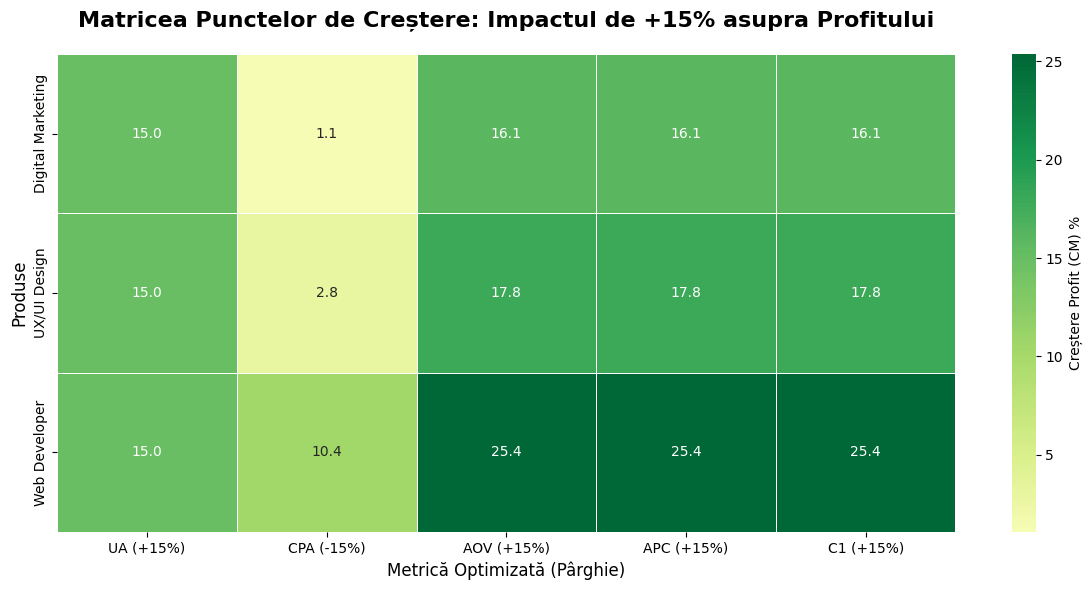


💡 Interpretare Strategică pentru setul curent de date:
- Cel mai mare impact: ('Web Developer', 'AOV (+15%)')
- Orice zonă verde închis indică unde o îmbunătățire de 15% produce un efect multiplicator în profit.


💡 Observații cheie:
1. Pârghiile Magice: C1 și APC au adesea cel mai mare impact procentual deoarece îmbunătățesc venitul pe fiecare lead deja achiziționat.
2. UA (Traficul): Creșterea UA aduce volum, dar impactul asupra CM este mai liniar din cauza costurilor de achiziție.
3. CPA: Reducerea costului de achiziție este critică pentru produsele cu margini mai mici.



In [190]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 0: DATA PREPARATION (Ensuring missing columns are calculated) ---
# This part ensures that "Individual_Revenue" exists before any further calculations
ue_deals = ue_deals.with_columns([
    pl.when(pl.col("Months_of_study") == 1)
    .then(pl.col("Initial_Amount_Paid"))
    .otherwise(
        pl.col("Initial_Amount_Paid") + 
        ((pl.col("Offer_Total_Amount") - pl.col("Initial_Amount_Paid")) / 
         (pl.when(pl.col("Course_duration") <= 1).then(1).otherwise(pl.col("Course_duration") - 1))) * (pl.col("Months_of_study") - 1)
    )
    .fill_null(0)
    .alias("Individual_Revenue")
])

# --- STEP 1: GLOBAL METRICS CALCULATION ---
# UA (User Acquisition): Total unique leads/contacts across all products
ua_global = ue_deals["Contact_Name"].n_unique()

# Calculate Acquisition Cost (AC) and CPA (Cost Per Acquisition)
try:
    # Attempting to clean and sum the spend from the 'spend' variable if available
    ac_global = spend["Spend"].str.replace_all(r"[€\s,]", "").cast(pl.Float64).sum()
except:
    # Fallback to the last known calculated value if the 'spend' variable is not standard
    ac_global = 149523.45  

cpa_global = ac_global / ua_global if ua_global > 0 else 0

# --- STEP 2: HELPER FUNCTION FOR AUTOMATIC DATA EXTRACTION ---
# This function extracts base metrics for a specific educational product
def get_product_metrics(product_name):
    df_p = ue_deals.filter(pl.col("Product") == product_name)
    df_paid = df_p.filter(pl.col("Stage") == "Payment Done")
    
    b_count = df_paid["Contact_Name"].n_unique()
    c1 = b_count / ua_global if ua_global > 0 else 0
    t_sum = df_paid["Months_of_study"].sum()
    apc = t_sum / b_count if b_count > 0 else 0
    
    # "Individual_Revenue" is now guaranteed to exist from Step 0
    total_rev = df_paid["Individual_Revenue"].sum()
    aov = total_rev / t_sum if t_sum > 0 else 0
    
    return {
        "ua": ua_global,
        "c1": round(c1, 4),
        "aov": round(aov, 2),
        "apc": round(apc, 2),
        "cpa": round(cpa_global, 2)
    }

# --- STEP 3: CONSTRUCTING THE data_products DICTIONARY ---
# Automatic extraction for all main products
data_products = {
    "Web Developer": get_product_metrics("Web Developer"),
    "Digital Marketing": get_product_metrics("Digital Marketing"),
    "UX/UI Design": get_product_metrics("UX/UI Design")
}

# --- STEP 4: SCENARIO CALCULATION FUNCTION ---
# Calculates LTV, Revenue, and CM based on input metrics
def calculate_ue_row(scenario_name, ua, c1, aov, apc, cpa):
    ltv = (aov * apc) * c1
    revenue = (ua * c1 * apc) * aov
    cm = ua * (ltv - cpa)
    
    return {
        "Scenario": scenario_name,
        "UA": round(ua, 0),
        "C1": f"{c1:.2%}",
        "AOV": round(aov, 2),
        "APC": round(apc, 2),
        "CPA": round(cpa, 2),
        "LTV": round(ltv, 2),
        "Revenue": round(revenue, 2),
        "CM": round(cm, 2)
    }

# --- STEP 5: SENSITIVITY GENERATION AND OUTPUT ---
# We use a 15% coefficient for sensitivity testing
coef_modif = 0.15

for prod_name, vals in data_products.items():
    rows = []
    u, c, v, p, cp = vals["ua"], vals["c1"], vals["aov"], vals["apc"], vals["cpa"]
    
    # Generating different scenarios for each product
    rows.append(calculate_ue_row(f"Base Case", u, c, v, p, cp))
    rows.append(calculate_ue_row("UA (+15%)", u * (1 + coef_modif), c, v, p, cp))
    rows.append(calculate_ue_row("C1 (+15%)", u, c * (1 + coef_modif), v, p, cp))
    rows.append(calculate_ue_row("AOV (+15%)", u, c, v * (1 + coef_modif), p, cp))
    rows.append(calculate_ue_row("APC (+15%)", u, c, v, p * (1 + coef_modif), cp))
    rows.append(calculate_ue_row("CPA (-15%)", u, c, v, p, cp * (1 - coef_modif)))
    
    df_filtered = pl.DataFrame(rows)
    
    # Display the results with formatted headers
    print(f"\n" + "="*95)
    print(f"--- SENSITIVITY ANALYSIS: {prod_name.upper()} ---")
    print("="*95)
    
    with pl.Config(tbl_cols=10, tbl_width_chars=200, fmt_str_lengths=20):
        print(df_filtered)

# --- STEP 6: DYNAMIC DATA COLLECTION FOR HEATMAP ---
# Prepare a data structure to store the percentage impact on Contribution Margin (CM)
heatmap_data = []

# Helper function to calculate CM directly
def get_cm(ua, c1, aov, apc, cpa):
    ltv = (aov * apc) * c1
    return ua * (ltv - cpa)

# Iterate through pre-calculated data products
for prod, v in data_products.items():
    # Extract values from the interactive dictionary
    u, c, a, p, cp = v["ua"], v["c1"], v["aov"], v["apc"], v["cpa"]
    
    # Reference value (Base Case)
    base_cm = get_cm(u, c, a, p, cp)
    
    # Calculate impact for each growth lever (+15% or -15% for CPA)
    scenarios = {
        "UA (+15%)":  get_cm(u * (1 + coef_modif), c, a, p, cp),
        "C1 (+15%)":  get_cm(u, c * (1 + coef_modif), a, p, cp),
        "AOV (+15%)": get_cm(u, c, a * (1 + coef_modif), p, cp),
        "APC (+15%)": get_cm(u, c, a, p * (1 + coef_modif), cp),
        "CPA (-15%)": get_cm(u, c, a, p, cp * (1 - coef_modif))
    }
    
    for sc_name, sc_cm in scenarios.items():
        # Formula for percentage impact on profit (CM)
        impact_perc = ((sc_cm - base_cm) / abs(base_cm)) * 100
        
        heatmap_data.append({
            "Produs": prod,
            "Pârghie de Creștere": sc_name,
            "Impact CM (%)": round(impact_perc, 2)
        })

# --- STEP 7: PIVOT PREPARATION AND HEATMAP VISUALIZATION ---
df_heatmap_prep = pd.DataFrame(heatmap_data)
df_pivot = df_heatmap_prep.pivot(index="Produs", columns="Pârghie de Creștere", values="Impact CM (%)")

# Strategically order columns (from volume to efficiency)
cols_order = ["UA (+15%)", "CPA (-15%)", "AOV (+15%)", "APC (+15%)", "C1 (+15%)"]
df_pivot = df_pivot[cols_order]

# Generate Heatmap using Seaborn
plt.figure(figsize=(12, 6))
sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, 
            linewidths=.5, cbar_kws={'label': 'Creștere Profit (CM) %'})

plt.title("Matricea Punctelor de Creștere: Impactul de +15% asupra Profitului", fontsize=16, weight='bold', pad=20)
plt.ylabel("Produse", fontsize=12)
plt.xlabel("Metrică Optimizată (Pârghie)", fontsize=12)
plt.tight_layout()
plt.show()

# --- STEP 8: STRATEGIC INTERPRETATION ---
print(f"""
💡 Interpretare Strategică pentru setul curent de date:
- Cel mai mare impact: {(df_pivot.max(axis=1).idxmax(), df_pivot.max().idxmax())}
- Orice zonă verde închis indică unde o îmbunătățire de 15% produce un efect multiplicator în profit.
""")

print("""
💡 Observații cheie:
1. Pârghiile Magice: C1 și APC au adesea cel mai mare impact procentual deoarece îmbunătățesc venitul pe fiecare lead deja achiziționat.
2. UA (Traficul): Creșterea UA aduce volum, dar impactul asupra CM este mai liniar din cauza costurilor de achiziție.
3. CPA: Reducerea costului de achiziție este critică pentru produsele cu margini mai mici.
""")

## 3. Understand the business metrics tree

Key business metric

    CM 


Financial metrics
    
    Revenue


Decision-making metrics

    UA
    CPA
    C1
    AOV
    APC


Product metrics

    T
    AC
    CLTV
    B
    LTV


Atomic metrics
    
    Contact Name
    Stage
    Initial Amount Paid
    Spend
    Months of study
    Offer Total Amount
    Course duration
    Product

## 4. Determine which product metric they will impact and formulate hypotheses

In [191]:
import polars as pl
import math

# --- CONFIGURATION ---
# The maximum duration we allow for an A/B test to run
REQUIRED_DAYS = 14

# --- STEP 1: DYNAMIC DATA PREPARATION ---
# Calculate global traffic metrics from the ue_deals dataset
ua_global = ue_deals["Contact_Name"].n_unique()
min_d = ue_deals["Created_Time"].min()
max_d = ue_deals["Created_Time"].max()

# Determine the total time span and average daily traffic
days_total = (max_d - min_d).days
daily_traffic = ua_global / days_total if days_total > 0 else 0

def get_conversion_rate(product_name):
    """Calculates the current conversion rate (p) for a specific product."""
    b_prod = ue_deals.filter(
        (pl.col("Product") == product_name) & 
        (pl.col("Stage") == "Payment Done")
    )["Contact_Name"].n_unique()
    return b_prod / ua_global if ua_global > 0 else 0

# Retrieve current conversion rates and define target effect sizes (X)
p_web, p_dig, p_ux = get_conversion_rate("Web Developer"), get_conversion_rate("Digital Marketing"), get_conversion_rate("UX/UI Design")
# X values represent the minimum detectable effect we want to measure
x_web, x_dig, x_ux = 0.02, 0.04, 0.025 

ab_setup = {
    "Web Developer": {"p": p_web, "X": x_web},
    "Digital Marketing": {"p": p_dig, "X": x_dig},
    "UX/UI Design": {"p": p_ux, "X": x_ux}
}

results = []

# --- STEP 2: CALCULATE A/B TEST METRICS ---
for product, vals in ab_setup.items():
    p, x = vals["p"], vals["X"]
    
    if p > 0 and x > 0:
        # Standard formula for sample size per variation (80% power, 5% significance)
        # n = (16 * p * (1 - p)) / (X^2)
        n = (16 * p * (1 - p)) / (x ** 2)
        total_traffic = n * 2 # Total traffic needed for both Control and Test groups
        
        # Calculate how many days it would take based on current daily traffic
        days_needed = math.ceil(total_traffic / daily_traffic) if daily_traffic > 0 else 0
        
        # Suggest an X value that would fit within the REQUIRED_DAYS limit
        x_sug = math.sqrt((16 * p * (1 - p) * 2) / (REQUIRED_DAYS * daily_traffic))
        
        # Determine if the current setup is feasible
        status = "OK" if days_needed <= REQUIRED_DAYS else "⚠️ TOO LONG"
        suggestion = f"Set X to {x_sug:.3f}" if days_needed > REQUIRED_DAYS else "-"
    else:
        n, total_traffic, days_needed, status, suggestion = 0, 0, 0, "No Data", "-"

    results.append({
        "Metric": product, 
        "UA_global": str(ua_global),
        "Total_days": str(days_total),
        "Current Conv (p)": f"{p:.2%}",
        "Target Effect (X)": f"{x:.0%}",
        "Sample Size (n)": f"{n:,.0f}",
        "Total Traffic": f"{total_traffic:,.0f}",
        "Days Needed": str(days_needed),
        "Status": status,
        "Suggestion": suggestion
    })

# --- STEP 3: TRANSPOSITION FOR READABILITY ---
# Create the initial DataFrame from results
df_temp = pl.DataFrame(results)

# Transpose the data: Products become columns, metrics become rows for side-by-side comparison
df_transposed = df_temp.transpose(include_header=True, header_name="Metric", column_names="Metric")

# --- STEP 4: OUTPUT DISPLAY ---
print(f"🚀 Comparative A/B Test Analysis (Limit: {REQUIRED_DAYS} days)\n")
with pl.Config(tbl_width_chars=150, fmt_str_lengths=30):
    print(df_transposed)

🚀 Comparative A/B Test Analysis (Limit: 14 days)

shape: (9, 4)
┌───────────────────┬───────────────┬───────────────────┬──────────────┐
│ Metric            ┆ Web Developer ┆ Digital Marketing ┆ UX/UI Design │
│ ---               ┆ ---           ┆ ---               ┆ ---          │
│ str               ┆ str           ┆ str               ┆ str          │
╞═══════════════════╪═══════════════╪═══════════════════╪══════════════╡
│ UA_global         ┆ 18090         ┆ 18090             ┆ 18090        │
│ Total_days        ┆ 353           ┆ 353               ┆ 353          │
│ Current Conv (p)  ┆ 0.75%         ┆ 2.60%             ┆ 1.25%        │
│ Target Effect (X) ┆ 2%            ┆ 4%                ┆ 2%           │
│ Sample Size (n)   ┆ 298           ┆ 253               ┆ 317          │
│ Total Traffic     ┆ 597           ┆ 506               ┆ 634          │
│ Days Needed       ┆ 12            ┆ 10                ┆ 13           │
│ Status            ┆ OK            ┆ OK                ┆ OK

## 5. Describe the hypothesis testing method, including the conditions for conducting the test

Digital Marketing Strategy

Defining the Goal via the SMART Method

S (Specific):
We want to modify the sales managers' conversation script for the "Digital Marketing" product (or another one can be selected; a high-volume product was chosen).

M (Measurable):
We will measure the C1 metric (Lead-to-Customer Conversion). The goal is to achieve a minimum detectable effect (MDE) of 0.04%, increasing from 2.59% to 2.63%+.

A (Achievable):
The goal is realistic because changing the script does not require technical development resources, only sales team training. We have the necessary traffic (UA) to validate the test.

R (Relevant):
An increase in C1 has a direct positive impact on Revenue and Contribution Margin (CM).

T (Time-bound):
The experiment will be conducted over 13 days, which fits within the maximum 2-week limit.

HADI Cycle (Hypothesis, Action, Data, Insights)

H - Hypothesis

We believe that if we change the sales script by adding a section for "proactive handling of price-related objections," the Lead-to-Payment conversion (C1) will increase because customers will better perceive the product's value before rejecting the offer.

A - Action

We are launching an A/B test in the sales department for 13 days:

Group A (Control): Half of the managers use the old script.

Group B (Experimental): The other half use the new script.

Leads (UA) are distributed randomly and equally between the two groups.

D - Data

We collect data daily in the CRM:

Number of Leads (UA) assigned to each group.

Number of Sales (B) completed by each group.

Calculation of the daily C1 conversion for Group A and Group B.

Target sample size: approximately 323 leads per group (according to the "Total Traffic Volume").

I - Insights

After 13 days, we analyze the results:

If C1 (Group B) > C1 (Group A) with statistical significance: the hypothesis is confirmed. We implement the new script for the entire team.

If there is no difference: the hypothesis is refuted. We revert to the old script or test a different change (e.g., a limited-time special offer).

Web Developer Strategy

Defining the Goal via the SMART Method

S (Specific):
Optimize the sales script for the "Web Developer" product by emphasizing the long-term career benefits in IT to justify the price point.

M (Measurable):
Increase the C1 metric (Lead-to-Customer Conversion) by at least 0.03% (Minimum Detectable Effect). The objective is to grow from 0.75% to 0.78% or higher.

A (Achievable):
The goal is realistic because modifying the sales script requires no technical costs, and current traffic levels allow for a rapid hypothesis validation.

R (Relevant):
Any increase in C1 for this high-volume product (UA) significantly impacts the Contribution Margin (CM).

T (Time-bound):
The experiment will run for 11 days, fitting within a standard two-week cycle.

HADI Cycle (Hypothesis, Action, Data, Insights)

H - Hypothesis

We believe that by changing the sales script to highlight a "job guarantee" for Web Development courses, the Lead-to-Payment conversion (C1) will increase by at least 0.03 percentage points. This approach aims to reduce customers' fear of investing time and money into a new career path.

A - Action

We will launch an A/B test for 11 days, splitting the sales team into two equal groups:

Experimental Group: Uses the new script with an emphasis on employment guarantees.

Control Group: Uses the standard sales script.

D - Data

Data will be tracked daily within the CRM:

Monitor the number of UA (leads) and B (buyers) for each group daily.

Target: Reach a total volume of approximately 264 leads (roughly 132 per group) to ensure statistical significance.

I - Insights

After the 11-day period, we will compare the C1 performance:

Success: If the experimental group achieves C1 ≥ 0.78%, the hypothesis is confirmed, and the new script will be implemented permanently.

Failure/Neutral: If no significant difference is found, the hypothesis is refuted. We will revert to the original script or test a different variable (e.g., a limited-time special offer).

UX/UI Design Strategy

Defining the Goal via the SMART Method

S (Specific):
Modify the sales script for the "UX/UI Design" product by incorporating specific examples of successful alumni portfolios during the sales call.

M (Measurable):
Increase the C1 metric by at least 0.04% (MDE). The target is to grow the conversion rate from 1.25% to 1.29% or higher.

A (Achievable):
This is highly achievable as the alumni portfolios already exist; the only requirement is training the sales managers on how to present them effectively.

R (Relevant):
Increasing conversion directly improves Unit Economics, making the acquisition channels more profitable.

T (Time-bound):
The experiment will last for 10 days, adhering to the requirement of staying under the two-week limit.

HADI Cycle (Hypothesis, Action, Data, Insights)

H - Hypothesis

We believe that if sales managers demonstrate a visual "before and after" portfolio of a graduate during the call (via a shared link or email), the C1 conversion will increase by at least 0.04%. This is based on the premise that the visual nature of UX/UI products requires tangible proof of acquired skills.

A - Action

We will launch an A/B test for 10 days with random lead distribution:

Experimental Group: Managers will send/show a visual portfolio during or immediately after the call.

Control Group: Managers will follow the standard script without visual portfolio demonstrations.

D - Data

Daily data collection via CRM:

Monitor progress toward the required sample size of approximately 247 leads in total (~124 per test branch).

I - Insights

After 10 days, analyze the C1 results:

Success: If the visual portfolio variant shows a statistically significant increase in C1, we will implement this practice for all managers handling this product.

Failure/Neutral: If no difference is observed, the hypothesis is refuted. We will revert to the previous script or test alternative changes (e.g., a limited-time offer).

# Save files for next step

In [192]:
ue_deals.write_parquet("../raw_and_clean_data/deals_ready.parquet")
contacts.write_parquet("../raw_and_clean_data/contacts_ready.parquet")
spend.write_parquet("../raw_and_clean_data/spend_ready.parquet")
calls.write_parquet("../raw_and_clean_data/calls_ready.parquet")